# What this notebook is doing (ERA5 / seasonal precip comparison)

This notebook compares meteorological season precipitation totals across the datasets I have been using for Skagit.
The main idea is to see how ERA5 and the other products line up by season, not just for the full basin but also for the main sub-basins.

It computes seasonal precipitation totals for DJF, MAM, JJA, and SON for Upper Skagit, Sauk, Lower Skagit, and Full Skagit.
The notebook then puts the datasets on the same plots, writes out the seasonal totals, and also calculates the error relative to PRISM so I can compare how far each source is from the PRISM baseline.

There are a few older versions of the workflow still in here, but the later code cell is the more complete one with the 4-region setup, the updated HRRR handling, and the final CSV/PNG outputs.

#### Code progress is recorded from first cell to last, to see the right output, scroll down to the last code cell

[HRRR] months available: 2014-12 … 2024-12 (n=121)
[HRRR] DJF 2014: missing months ['2013-12', '2014-01', '2014-02'] -> skipping
[HRRR] DJF 2015: Upper Skagit=541.8, Sauk=570.5, Lower Skagit=525.0
[HRRR] DJF 2016: Upper Skagit=788.4, Sauk=831.9, Lower Skagit=770.3
[HRRR] DJF 2017: Upper Skagit=443.4, Sauk=540.0, Lower Skagit=494.4
[HRRR] DJF 2018: Upper Skagit=668.4, Sauk=828.6, Lower Skagit=783.4
[HRRR] DJF 2019: Upper Skagit=692.5, Sauk=739.1, Lower Skagit=582.3
[HRRR] DJF 2020: Upper Skagit=869.6, Sauk=1134.5, Lower Skagit=890.5
[HRRR] DJF 2021: Upper Skagit=740.4, Sauk=961.2, Lower Skagit=726.0
[HRRR] DJF 2022: Upper Skagit=555.9, Sauk=763.5, Lower Skagit=597.2
[HRRR] DJF 2023: Upper Skagit=506.8, Sauk=638.9, Lower Skagit=566.1
[HRRR] DJF 2024: Upper Skagit=352.0, Sauk=474.3, Lower Skagit=402.1
[HRRR] MAM 2014: missing months ['2014-03', '2014-04', '2014-05'] -> skipping
[HRRR] MAM 2015: Upper Skagit=246.9, Sauk=260.9, Lower Skagit=239.1
[HRRR] MAM 2016: Upper Skagit=265.7, Sauk=33

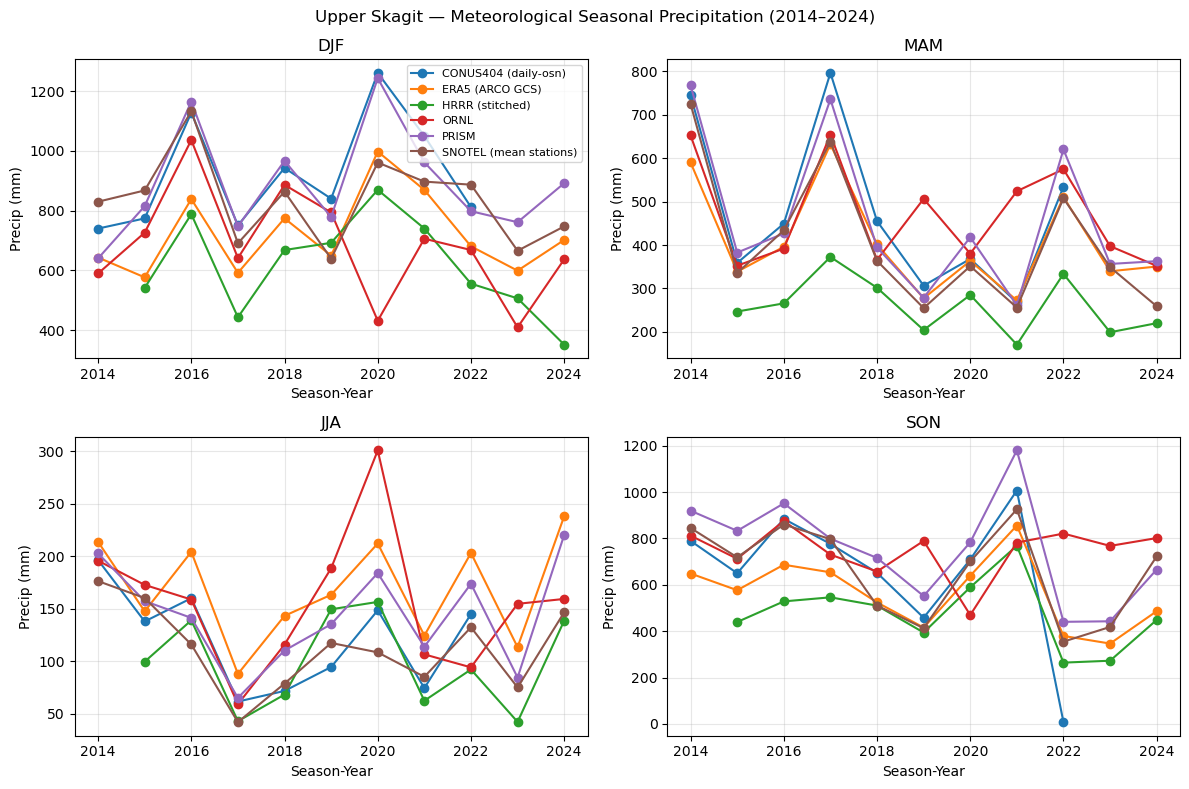

Saved plot → /data0/balaji24/data/derived/met_season_precip_Sauk_2014_2024.png


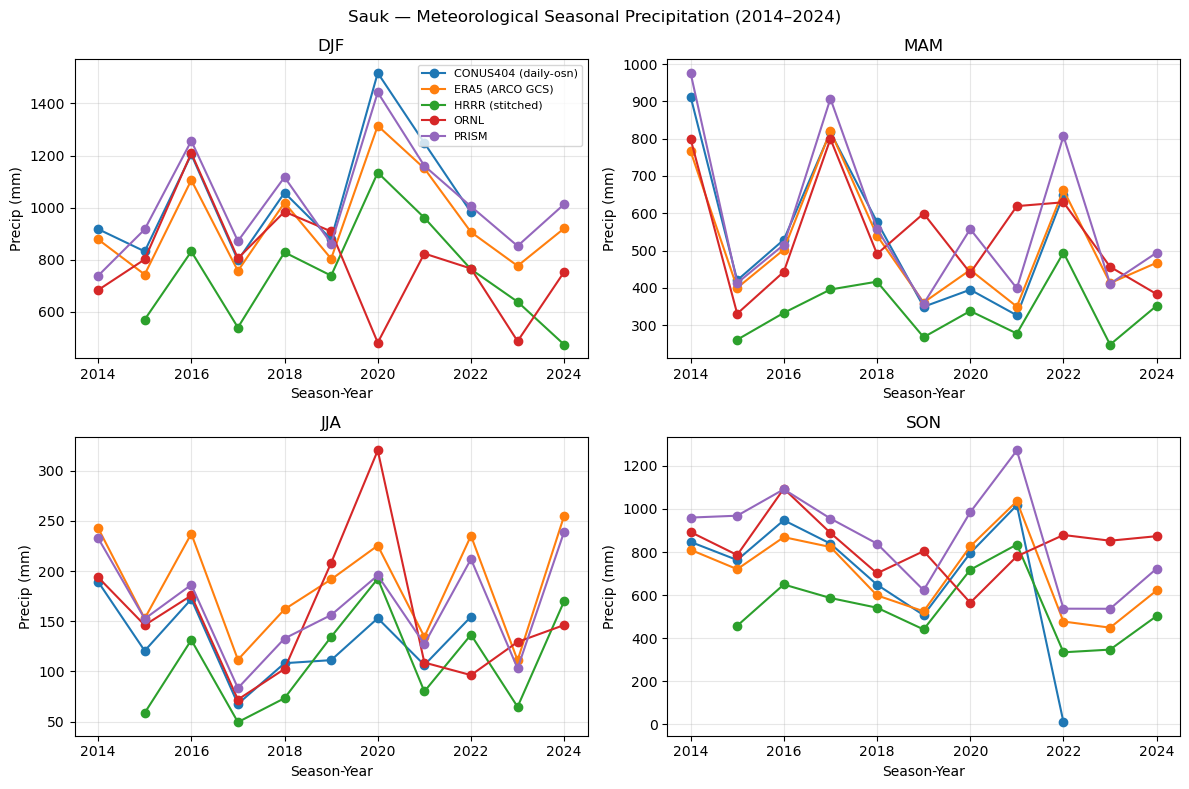

Saved plot → /data0/balaji24/data/derived/met_season_precip_Lower_Skagit_2014_2024.png


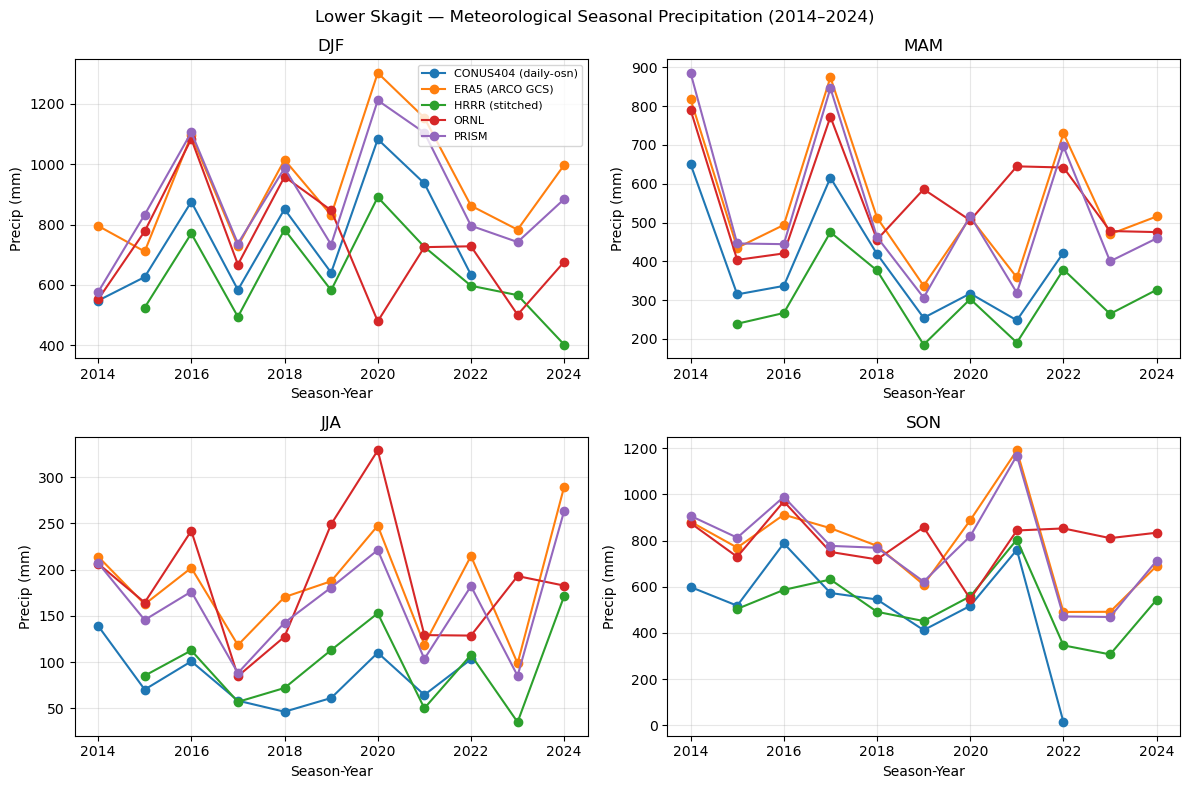

Saved summary plot → /data0/balaji24/data/derived/met_season_precip_skagit_regions_2014_2024_ALL.png


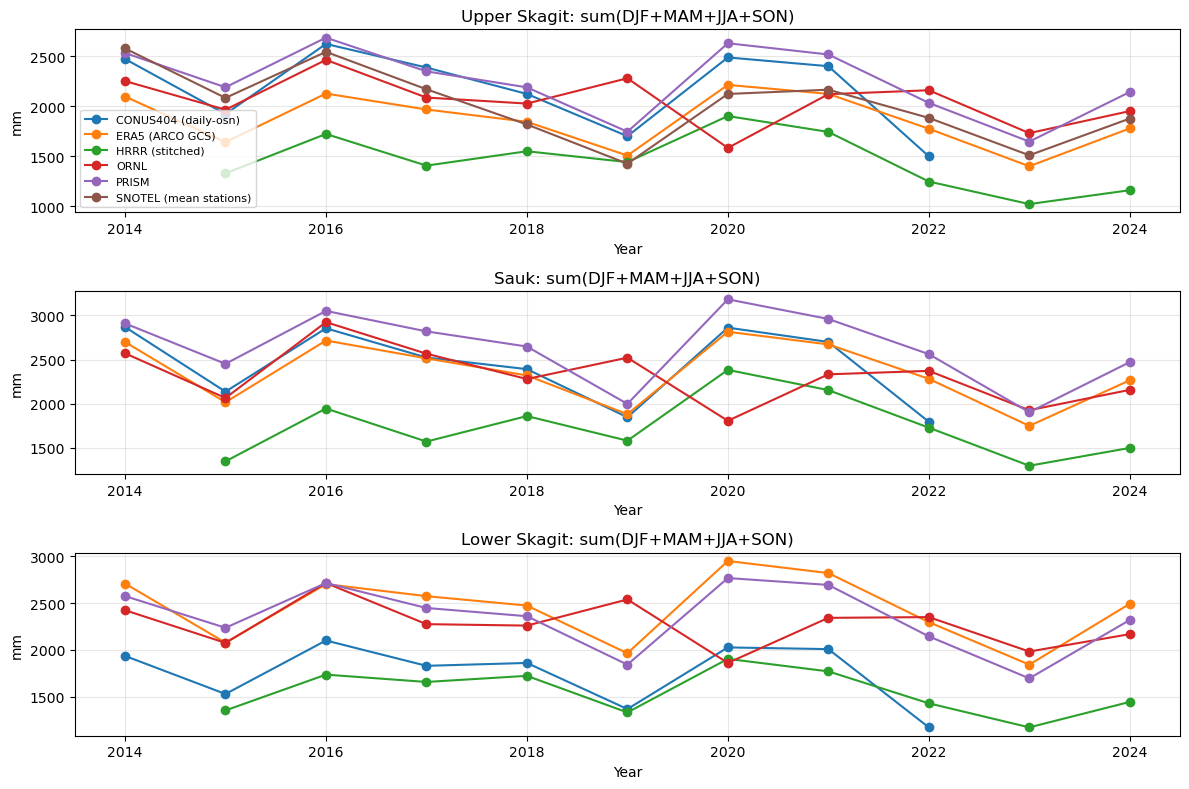


[MAE vs PRISM] Per (region, season, year) (mm):
           region season  year                 dataset      mae_mm
0    Lower Skagit    DJF  2014    CONUS404 (daily-osn)   28.165770
1    Lower Skagit    DJF  2014         ERA5 (ARCO GCS)  219.546396
2    Lower Skagit    DJF  2014         HRRR (stitched)         NaN
3    Lower Skagit    DJF  2014                    ORNL   24.248724
4    Lower Skagit    DJF  2014  SNOTEL (mean stations)         NaN
..            ...    ...   ...                     ...         ...
655  Upper Skagit    SON  2024    CONUS404 (daily-osn)         NaN
656  Upper Skagit    SON  2024         ERA5 (ARCO GCS)  179.759284
657  Upper Skagit    SON  2024         HRRR (stitched)  217.481896
658  Upper Skagit    SON  2024                    ORNL  135.705257
659  Upper Skagit    SON  2024  SNOTEL (mean stations)   56.636730

[660 rows x 5 columns]
Saved MAE CSV → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_skagit_regions_2014_2024.csv
Saved MAE plot → /data0/b

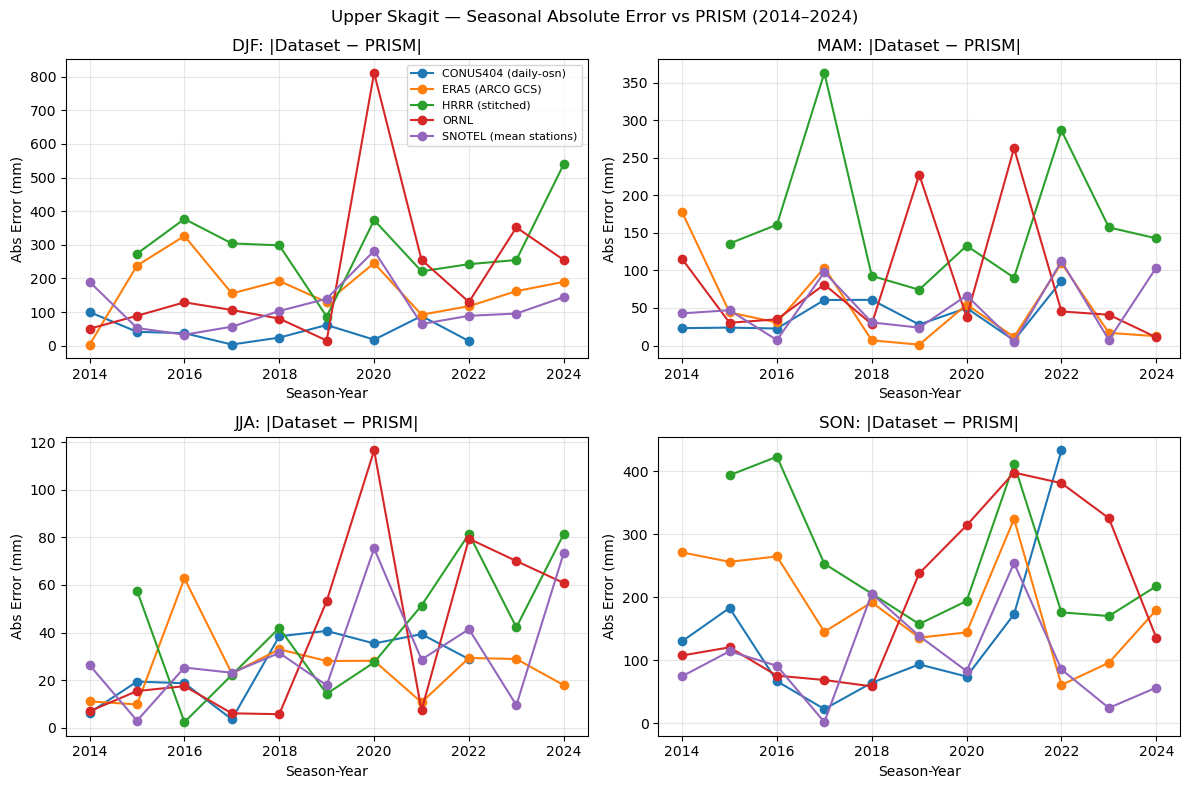

Saved MAE plot → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_Sauk_2014_2024.png


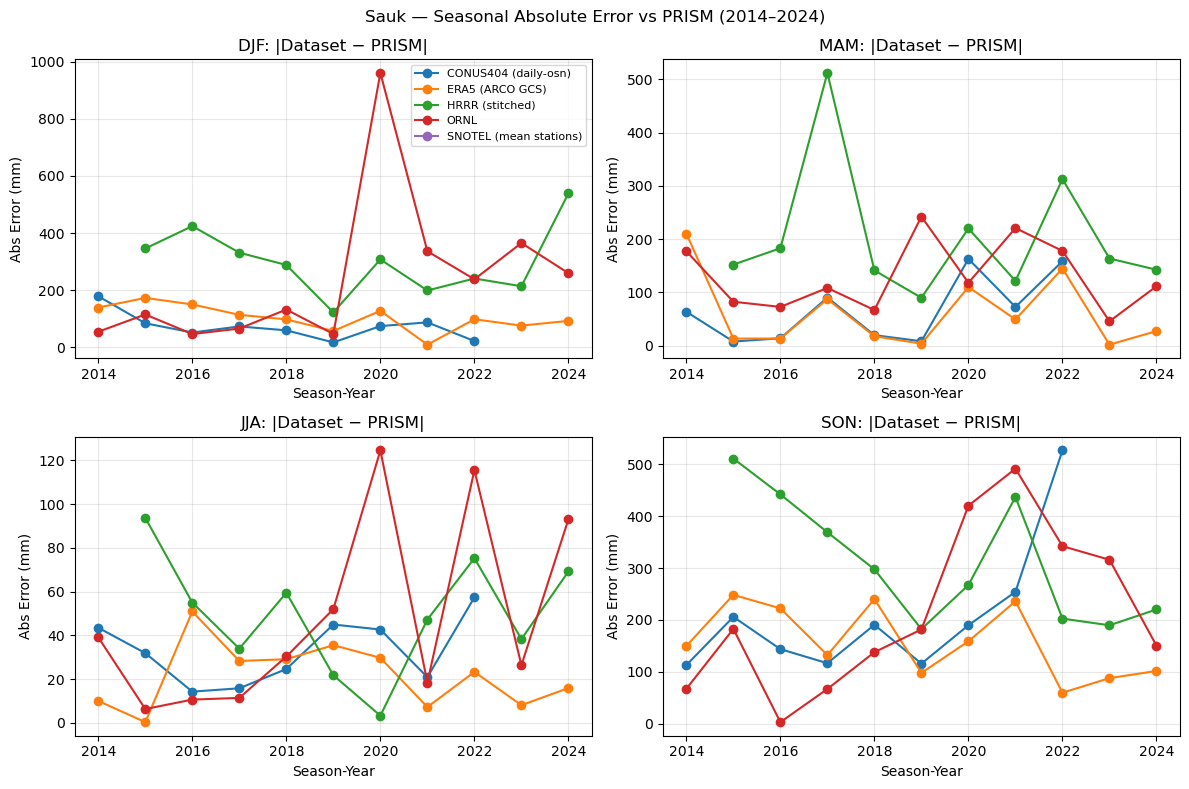

Saved MAE plot → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_Lower_Skagit_2014_2024.png


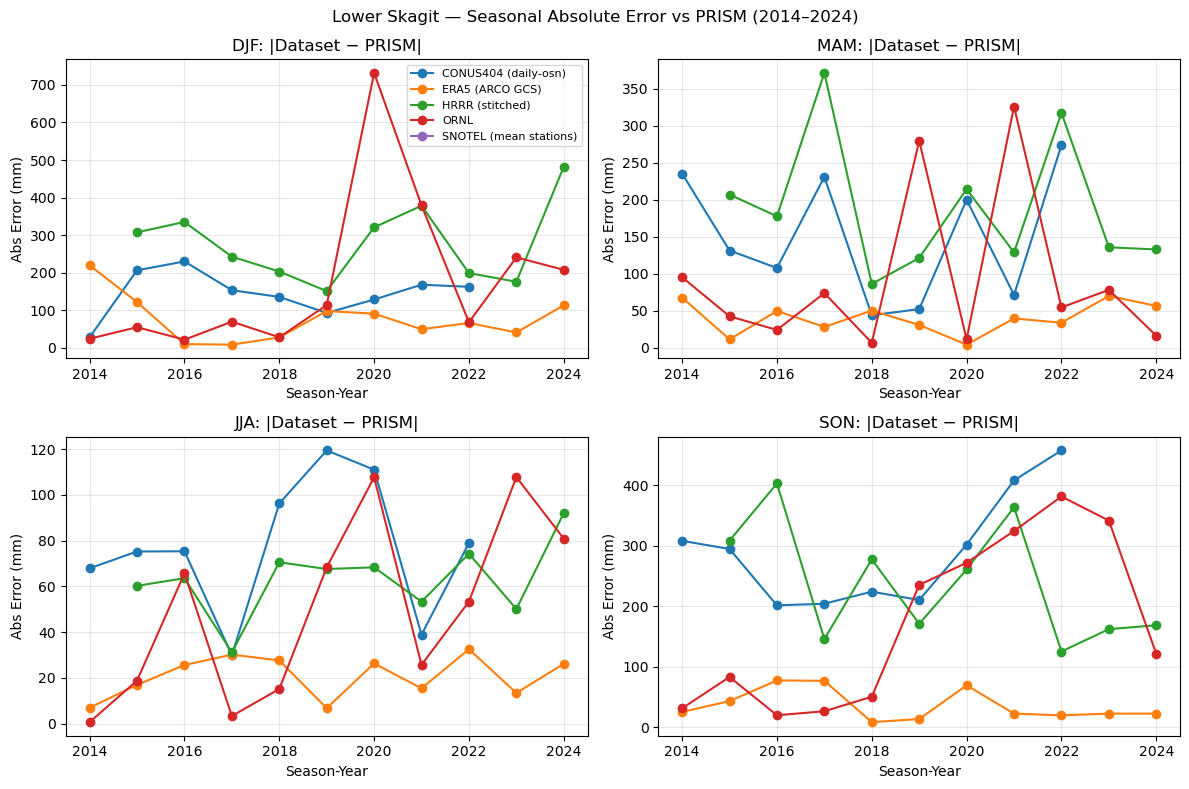

Saved MAE summary plot → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_skagit_regions_2014_2024.png


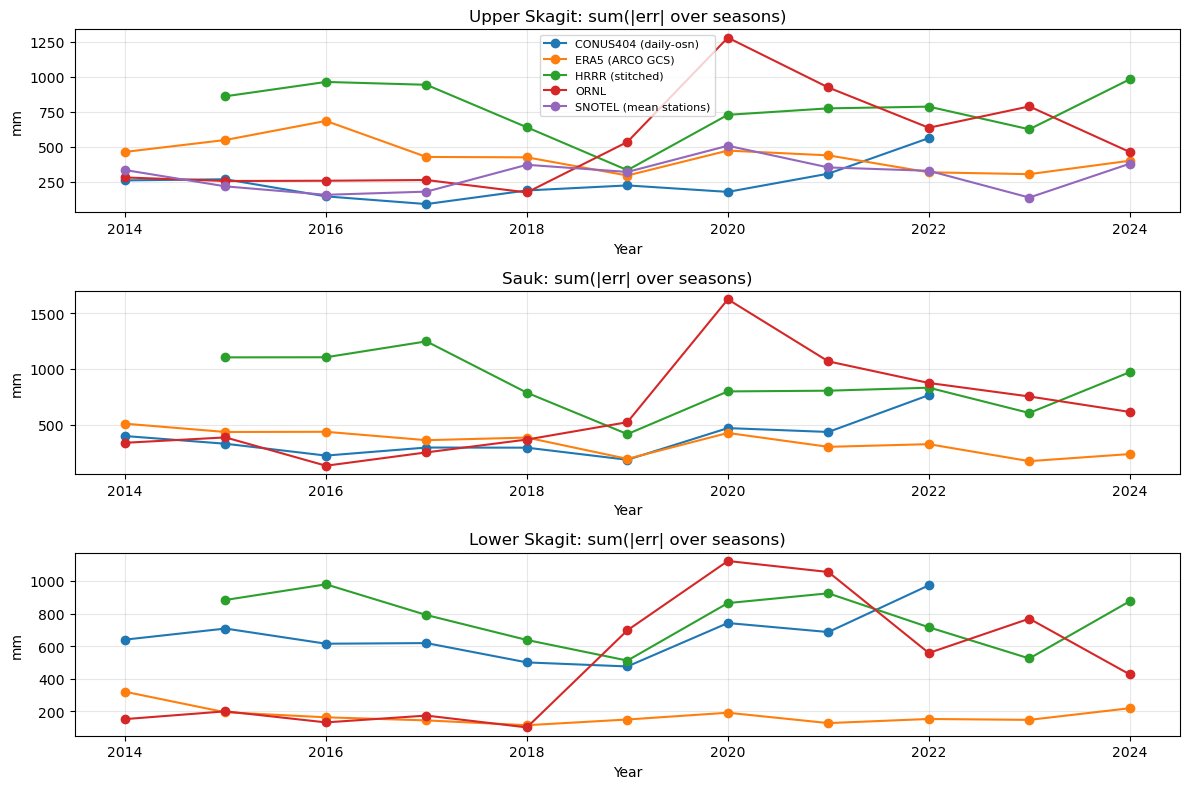

In [ ]:
# ============================
# Skagit Basin — METEOROLOGICAL SEASON Precip (mm) by dataset (DJF/MAM/JJA/SON)
# NOW BY 3 REGIONS (HUC8-dominant sub-basins):
#   - Upper Skagit
#   - Sauk
#   - Lower Skagit
#
# Safe, de-accumulating where needed, robust to duplicates
#
# METEOROLOGICAL SEASONS:
#   - DJF = Dec(previous year) + Jan/Feb(current year)  labeled by ending year
#   - MAM = Mar/Apr/May (year)
#   - JJA = Jun/Jul/Aug (year)
#   - SON = Sep/Oct/Nov (year)
#
# ADD:
# - Per-(region,season,year) absolute error (|err|) vs PRISM for all other datasets
#
# ============================

import json, re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2024   # season-year labels (DJF labeled by ending year)

# dataset roots
P_ORNL_DIR   = BASE / "ornl"
P_PRISM_DIR  = BASE / "prism_ppt"
P_HRRR_DIR   = BASE / "weather_data"             # many YYYY-MM_HRRR_data.zarr
P_WRF_DIR    = BASE / "ucla_wrf_outputs"         # yearly zarrs
PNNL_HIST    = BASE / "PNNL" / "historical"      # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

# outputs
CSV_OUT = OUT / f"met_season_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"
PNG_OUT = OUT / f"met_season_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.png"

MAE_REF = "PRISM"
MAE_CSV_OUT = OUT / f"met_season_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.csv"
MAE_PNG_OUT = OUT / f"met_season_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.png"

# 3-region definition (dominant HUC8s inside Skagit)
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_incremental_mm(da, force_cumulative=False):
    """Normalize precip to incremental per-step in mm; deaccumulate if cumulative."""
    units = str(da.attrs.get("units", "")).lower()
    name  = (da.name or "").lower()

    if units.strip() in {"m", "meter", "meters"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"

    if "kg m" in units and "-2" in units:
        da.attrs["units"] = "mm"

    is_cum = (
        force_cumulative
        or any(k in name for k in ["prec_acc_nc", "rainnc", "rainc", "acc"])
        or ("cumulative" in units)
    )

    da = ensure_time_sorted_unique(da)

    if is_cum:
        inc = da.diff("time", label="upper")
        inc = inc.where(inc >= 0, 0)  # clip resets
        inc = xr.concat([da.isel(time=slice(0, 1)) * 0, inc], dim="time")
        inc.attrs["units"] = "mm"
        return inc

    return da

# ---- plotting helper: convert 0 NaN ONLY for plotting ----
def plot_nozero_line(ax, x, y, *, marker="o", label=None):
    """Matplotlib line plot that hides zeros by converting them to NaN."""
    if hasattr(y, "where"):
        y_plot = y.where(y != 0)
    else:
        y_plot = np.where(np.asarray(y) != 0, y, np.nan)
    ax.plot(x, y_plot, marker=marker, label=label)

# ---------------- Region handling ----------------
def load_regions_gdf():
    """Load the 3 dominant HUC8 polygons, clipped to Skagit boundary."""
    import geopandas as gpd

    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if huc8_3.empty:
        raise ValueError(
            f"No matching HUC8 regions found for {REGION_NAMES}. "
            f"Check HUC8_GEO path and the 'Name' field values."
        )

    # clip each HUC8 polygon to Skagit boundary (ensures no outside slivers)
    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    # preserve desired order
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def _to_2d(arr):
    """Take a lat/lon-like array and reduce it to 2D (y,x) or (lat,lon)."""
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def region_mean(da, grid_ds=None, regions_gdf=None):
    """
    Mean(da) inside each region polygon.
    Returns DataArray with an added 'region' dimension.
    """
    if regions_gdf is None:
        raise ValueError("regions_gdf is required for region_mean")

    try:
        import regionmask
    except Exception as e:
        raise RuntimeError(f"regionmask is required for region_mean: {e}")

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        out = da
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    lat_name, lon_name = find_lat_lon_names(host)
    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(host[lon_name])
    lat = _to_2d(host[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )

    rid = regs.mask(lon, lat)

    out_list = []
    for i, rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

# ---------------- MET SEASON helpers ----------------
SEASONS = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}

def season_year_index(time_da, season_label):
    """DJF labeled by ending year (Dec - y+1). Others labeled by calendar year."""
    y = time_da.dt.year
    m = time_da.dt.month
    if season_label == "DJF":
        return xr.where(m == 12, y + 1, y)
    return y

def seasonal_sum_mm(da, season_label):
    """
    Sum over a meteorological season grouped by season-year.
    Works for da with dims like ('time', 'region') or ('time',).
    """
    if "time" not in da.dims:
        return None
    da = ensure_time_sorted_unique(da)
    months = SEASONS[season_label]
    da_s = da.where(da["time"].dt.month.isin(months), drop=True)
    if da_s.sizes.get("time", 0) == 0:
        return None
    sy = season_year_index(da_s["time"], season_label)
    out = da_s.groupby(sy).sum("time", skipna=True)
    out = out.rename({"group": "year"}) if "group" in out.dims else out
    out.name = "mm"
    return out

def pick_year(ann, year):
    """(Legacy helper) kept for compatibility with previous style."""
    if ann is None:
        return np.nan
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=year).values)
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: year}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

def season_time_window(year, season_label):
    """Return ISO start/end strings (inclusive slice) for season-year."""
    def month_end(y, m):
        return (pd.Timestamp(y, m, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

    if season_label == "DJF":
        start = pd.Timestamp(year - 1, 12, 1).strftime("%Y-%m-%d")
        end   = month_end(year, 2)
        return start, end
    if season_label == "MAM":
        return f"{year}-03-01", month_end(year, 5)
    if season_label == "JJA":
        return f"{year}-06-01", month_end(year, 8)
    if season_label == "SON":
        return f"{year}-09-01", month_end(year, 11)
    raise ValueError(season_label)

# --------- HRRR robust deaccumulation ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    run_coord = next((c for c in ("run", "init", "forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step", "lead", "forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)

    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

def hrrr_month_prefixes_for_season_year(year: int, season_label: str):
    if season_label == "DJF":
        return {f"{year-1}-12", f"{year}-01", f"{year}-02"}
    if season_label == "MAM":
        return {f"{year}-03", f"{year}-04", f"{year}-05"}
    if season_label == "JJA":
        return {f"{year}-06", f"{year}-07", f"{year}-08"}
    if season_label == "SON":
        return {f"{year}-09", f"{year}-10", f"{year}-11"}
    raise ValueError(season_label)

# ---------------- Collectors ----------------
regions_gdf = load_regions_gdf()
rows = []

GLOBAL_START = f"{YEAR_MIN-1}-12-01"
GLOBAL_END   = (pd.Timestamp(YEAR_MAX, 11, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

# ---------- ORNL ----------
if P_ORNL_DIR.exists():
    ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if ornl_years:
        dso = xr.concat(
            [safe_open_zarr(p) for p in ornl_years],
            dim="time", join="outer", coords="minimal", compat="override"
        )
        if "prcp" in dso:
            da = ensure_time_sorted_unique(dso["prcp"])
            rm = region_mean(da, grid_ds=dso, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))

            for s in SEASONS.keys():
                ann = seasonal_sum_mm(rm, s)  # dims: (year, region)
                if ann is None:
                    continue
                for yr in range(YEAR_MIN, YEAR_MAX + 1):
                    for rname in ann["region"].values:
                        try:
                            val = float(ann.sel(year=yr, region=rname).values)
                        except Exception:
                            val = np.nan
                        if not np.isnan(val):
                            rows.append({"dataset": "ORNL", "region": str(rname), "season": s, "year": yr, "mm": val})

# ---------- PRISM ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time", join="outer", coords="minimal", compat="override"
        )
        v = next((v for v in ["ppt", "precip", "prcp"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])
            rm = region_mean(da, grid_ds=dsp, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))

            for s in SEASONS.keys():
                ann = seasonal_sum_mm(rm, s)  # dims: (year, region)
                if ann is None:
                    continue
                for yr in range(YEAR_MIN, YEAR_MAX + 1):
                    for rname in ann["region"].values:
                        try:
                            val = float(ann.sel(year=yr, region=rname).values)
                        except Exception:
                            val = np.nan
                        if not np.isnan(val):
                            rows.append({"dataset": "PRISM", "region": str(rname), "season": s, "year": yr, "mm": val})

# ---------- HRRR ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
available = {p.name[:7] for p in monthly}

if monthly:
    available_prefixes = sorted(list(available))
    print(f"[HRRR] months available: {available_prefixes[0]} … {available_prefixes[-1]} (n={len(available_prefixes)})")

    for s in SEASONS.keys():
        for yr in range(YEAR_MIN, YEAR_MAX + 1):
            need = hrrr_month_prefixes_for_season_year(yr, s)
            missing = sorted(list(need - available))
            if missing:
                print(f"[HRRR] {s} {yr}: missing months {missing} -> skipping")
                continue

            parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])
            ds0 = safe_open_zarr(parts[0])

            var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
            if not var:
                print(f"[HRRR] {s} {yr}: no tp/apcp in {parts[0].name} -> skipping")
                try: ds0.close()
                except Exception: pass
                continue

            dsets = []
            ok = True
            for p in parts:
                dsm = safe_open_zarr(p)
                if var not in dsm:
                    print(f"[HRRR] {s} {yr}: {p.name} missing {var} -> skipping")
                    try: dsm.close()
                    except Exception: pass
                    ok = False
                    break
                dsets.append(dsm[[var]])

            if not ok:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

            hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
            if hourly_mm.sizes.get("time", 0) == 0:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            daily = hourly_mm.resample(time="1D").sum()
            rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
            rm_daily = ensure_time_sorted_unique(rm_daily)

            t0, t1 = season_time_window(yr, s)
            rm_daily = rm_daily.sel(time=slice(t0, t1))
            if rm_daily.sizes.get("time", 0) == 0:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            season_tot = rm_daily.sum("time", skipna=True)
            for rname in season_tot["region"].values:
                val = float(season_tot.sel(region=rname).values)
                rows.append({"dataset": "HRRR (stitched)", "region": str(rname), "season": s, "year": yr, "mm": val})

            print(f"[HRRR] {s} {yr}: " + ", ".join([f"{r}={float(season_tot.sel(region=r)):.1f}" for r in season_tot["region"].values]))

            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
else:
    print("[HRRR] No HRRR monthly zarrs found -> skipping HRRR.")

# ---------- ERA5 (ARCO on GCS) ----------
# Public Zarr v3 store on GCS:
# gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3
# Variable: total_precipitation (units: m) convert to mm

try:
    import gcsfs  # noqa: F401
except Exception as e:
    print(f"[ERA5] gcsfs not available ({e}) -> skipping ERA5.")
else:
    ERA5_STORE = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
    ERA5_DATASET_NAME = "ERA5 (ARCO GCS)"

    # Skagit-ish bbox (pad a bit)
    BBOX = dict(lat_min=48.0, lat_max=49.7, lon_min=-123.2, lon_max=-120.5)

    print(f"[ERA5] Opening {ERA5_STORE} (public, anon)...")
    ds_era5 = xr.open_zarr(
        ERA5_STORE,
        consolidated=False,
        storage_options={"token": "anon"},
        chunks={"time": 24 * 14},  # ~2 weeks of hours per chunk
    )

    # lon [-180, 180]
    if "longitude" in ds_era5.coords and float(ds_era5.longitude.min()) >= 0:
        ds_era5 = ds_era5.assign_coords(
            longitude=(((ds_era5.longitude + 180) % 360) - 180)
        ).sortby("longitude")

    if "total_precipitation" not in ds_era5:
        print("[ERA5] total_precipitation not found -> skipping ERA5.")
    else:
        tp = ds_era5["total_precipitation"]
        units = str(tp.attrs.get("units", "")).lower().strip()
        to_mm = 1000.0 if units in {"m", "meter", "meters", "metre", "metres"} else 1.0
        print(f"[ERA5] total_precipitation units={units!r} -> mm={to_mm==1000.0}")

        # latitude in ERA5 is often descending; handle both cases
        lat0, lat1 = BBOX["lat_min"], BBOX["lat_max"]
        if ds_era5.latitude[0] > ds_era5.latitude[-1]:
            lat_slice = slice(lat1, lat0)  # descending
        else:
            lat_slice = slice(lat0, lat1)  # ascending
        lon_slice = slice(BBOX["lon_min"], BBOX["lon_max"])

        # Build a small grid just for the subset for regionmask
        lat_sub = ds_era5["latitude"].sel(latitude=lat_slice)
        lon_sub = ds_era5["longitude"].sel(longitude=lon_slice)
        lon2d, lat2d = xr.broadcast(lon_sub, lat_sub)
        grid_era5 = xr.Dataset({"longitude": lon2d, "latitude": lat2d})

        for s in SEASONS.keys():
            for yr in range(YEAR_MIN, YEAR_MAX + 1):
                t0, t1 = season_time_window(yr, s)

                tp_h = (
                    tp.sel(time=slice(t0, t1), latitude=lat_slice, longitude=lon_slice)
                      .astype("float32") * to_mm
                ).clip(min=0)

                if tp_h.sizes.get("time", 0) == 0:
                    continue

                daily = tp_h.resample(time="1D").sum()
                rm_daily = region_mean(daily, grid_ds=grid_era5, regions_gdf=regions_gdf)
                rm_daily = ensure_time_sorted_unique(rm_daily)

                season_tot = rm_daily.sum("time", skipna=True)
                for rname in season_tot["region"].values:
                    val = float(season_tot.sel(region=rname).values)
                    if np.isfinite(val):
                        rows.append({
                            "dataset": ERA5_DATASET_NAME,
                            "region": str(rname),
                            "season": s,
                            "year": int(yr),
                            "mm": val
                        })

                msg = ", ".join([f"{r}={float(season_tot.sel(region=r)):.1f}" for r in season_tot["region"].values])
                print(f"[ERA5] {s} {yr}: {msg}")

    try:
        ds_era5.close()
    except Exception:
        pass

# ---------- SNOTEL ----------
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        skagit_geom = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326").geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
        if not skagit_stations.empty and "name" in skagit_stations.columns:
            skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            regs = regions_gdf.copy().to_crs("EPSG:4326")
            skagit_stations = skagit_stations.to_crs("EPSG:4326")

            try:
                joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name":"region"}), predicate="within", how="left")
            except TypeError:
                joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name":"region"}), op="within", how="left")

            joined = joined.dropna(subset=["region"])
            if joined.empty:
                print("[SNOTEL] Stations found but none fall within the 3 regions -> skipping.")
            else:
                print("[SNOTEL] Using stations by region:")
                for region in REGION_NAMES:
                    sub = joined[joined["region"] == region]
                    if sub.empty:
                        continue
                    names = sub["name"].tolist() if "name" in sub.columns else sub["code"].tolist()
                    print(f"  - {region}: {names}")

                base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"
                seasonal_values = {}  # (region, season, year) list of station totals

                for _, row in joined.iterrows():
                    code = row.get("code")
                    name = row.get("name", code)
                    region = row["region"]
                    if pd.isna(code):
                        continue

                    csv_url = f"{base_csv_url}/{code}.csv"
                    try:
                        df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                    except Exception as e:
                        print(f"[SNOTEL] Failed to read {code} ({name}): {e}")
                        continue

                    if "PRCPSA" not in df_s.columns:
                        print(f"[SNOTEL] No PRCPSA for {code} ({name}), skipping.")
                        continue

                    precip_mm = (df_s["PRCPSA"] * 1000.0).loc[GLOBAL_START:GLOBAL_END]
                    idx = precip_mm.index

                    month = idx.month.to_numpy()
                    year_arr = idx.year.to_numpy()

                    season = np.full(len(idx), "", dtype=object)
                    season[np.isin(month, [12, 1, 2])] = "DJF"
                    season[np.isin(month, [3, 4, 5])] = "MAM"
                    season[np.isin(month, [6, 7, 8])] = "JJA"
                    season[np.isin(month, [9, 10, 11])] = "SON"

                    season_year = year_arr.copy()
                    dec_mask = (season == "DJF") & (month == 12)
                    season_year[dec_mask] = season_year[dec_mask] + 1

                    tmp = pd.DataFrame({"mm": precip_mm.values, "season": season, "year": season_year}, index=idx)
                    tmp = tmp[(tmp["year"] >= YEAR_MIN) & (tmp["year"] <= YEAR_MAX)]
                    tmp = tmp[tmp["season"].isin(SEASONS.keys())]

                    agg = tmp.groupby(["season", "year"])["mm"].sum()
                    for (ss, yy), val in agg.items():
                        seasonal_values.setdefault((region, ss, int(yy)), []).append(float(val))

                for (region, ss, yy), vals in seasonal_values.items():
                    rows.append({
                        "dataset": "SNOTEL (mean stations)",
                        "region": str(region),
                        "season": ss,
                        "year": int(yy),
                        "mm": float(np.nanmean(vals))
                    })

# ---------- PNNL ----------
PNNL_REGION_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")

if PNNL_HIST.exists() and PNNL_REGION_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_REGION_MASK)
    if "mask" not in mask_ds:
        raise ValueError("[PNNL] Expected variable 'mask' in PNNL_REGION_MASK")
    if "region" not in mask_ds["mask"].dims:
        raise ValueError("[PNNL] Expected 'mask' to have a 'region' dimension")

    region_labels = [str(r) for r in mask_ds["region"].values]

    for s in SEASONS.keys():
        for yr in range(YEAR_MIN, YEAR_MAX + 1):
            years_needed = {yr}
            if s == "DJF":
                years_needed.add(yr - 1)

            files = []
            for yy in sorted(years_needed):
                files += sorted(glob(str(PNNL_HIST / f"{yy}" / "*PREC_ACC_NC*.nc")))
            if not files:
                continue

            dsp = xr.open_mfdataset(files, combine="by_coords", engine="netcdf4", parallel=False)
            v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
            if v is None:
                dsp.close()
                continue

            t0, t1 = season_time_window(yr, s)
            p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(t0, t1))
            if p.sizes.get("time", 0) == 0:
                dsp.close()
                continue

            P = p.sum(dim="time").values  # shape (y,x)
            for rname in region_labels:
                m = mask_ds["mask"].sel(region=rname).values.astype(bool)
                if P.shape != m.shape:
                    raise ValueError(f"[PNNL] Shape mismatch: {P.shape} vs mask {m.shape} for region {rname}")
                rows.append({
                    "dataset": "PNNL (historical)",
                    "region": rname,
                    "season": s,
                    "year": yr,
                    "mm": float(P[m].mean()),
                })
            dsp.close()
else:
    if PNNL_HIST.exists():
        print("[PNNL] Skipping regional PNNL: missing region mask file:", PNNL_REGION_MASK)

# ---------- CONUS404 ----------
try:
    import intake
    import geopandas as gpd  # noqa: F401
    import shapely
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(GLOBAL_START, GLOBAL_END))

        lat = ds["lat"]
        lon = ds["lon"]

        regs = regions_gdf.to_crs("EPSG:4326")

        for region in REGION_NAMES:
            geom = regs.loc[regs["Name"] == region, "geometry"].iloc[0]
            mask_np = shapely.contains_xy(geom, lon.values, lat.values)
            mask_da = xr.DataArray(mask_np, dims=("y", "x"))

            region_daily = precip.where(mask_da).mean(dim=("y", "x"))

            for s in SEASONS.keys():
                ann = seasonal_sum_mm(region_daily, s)
                if ann is None:
                    continue
                for yr in range(YEAR_MIN, YEAR_MAX + 1):
                    val = pick_year(ann, yr)
                    if not np.isnan(val):
                        rows.append({
                            "dataset": "CONUS404 (daily-osn)",
                            "region": region,
                            "season": s,
                            "year": yr,
                            "mm": float(val),
                        })

# ---------------- Results ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "region", "season", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["region", "dataset", "season", "year"])
      .reset_index(drop=True)
)

print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# ---------------- Plotting ----------------
seasons_order = ["DJF","MAM","JJA","SON"]

# One figure per region (cleanest)
for region in REGION_NAMES:
    df_r = df[df["region"] == region]
    if df_r.empty:
        continue

    fig = plt.figure(figsize=(12, 8))
    for i, s in enumerate(seasons_order, start=1):
        ax = plt.subplot(2, 2, i)
        dss = df_r[df_r["season"] == s]
        for name, g in dss.groupby("dataset"):
            # hide zeros on the plot
            g_plot = g.assign(mm=g["mm"].where(g["mm"] != 0))
            ax.plot(g_plot["year"], g_plot["mm"], marker="o", label=name)

        ax.set_title(s)
        ax.set_xlabel("Season-Year")
        ax.set_ylabel("Precip (mm)")
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.legend(fontsize=8)

    fig.suptitle(f"{region} — Meteorological Seasonal Precipitation ({YEAR_MIN}–{YEAR_MAX})", y=0.98)
    fig.tight_layout()
    out_png = OUT / f"met_season_precip_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.savefig(out_png, dpi=160)
    print("Saved plot →", out_png)
    plt.show()

# Combined PNG summary: total annualized seasonal sum (sum over seasons) by dataset.
summary = df.groupby(["region", "dataset", "year"], as_index=False)["mm"].sum()
fig = plt.figure(figsize=(12, 8))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = summary[summary["region"] == region]
    for name, g in sub.groupby("dataset"):
        # hide zeros on the plot
        g_plot = g.assign(mm=g["mm"].where(g["mm"] != 0))
        ax.plot(g_plot["year"], g_plot["mm"], marker="o", label=name)

    ax.set_title(f"{region}: sum(DJF+MAM+JJA+SON)")
    ax.set_xlabel("Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(PNG_OUT, dpi=160)
print("Saved summary plot →", PNG_OUT)
plt.show()

# ==========================================================
# NEW: Per-(region,season,year) absolute error vs PRISM
#   With one value per (season,year), "MAE per year" == |err|
# ==========================================================
wide = df.pivot_table(index=["region", "season", "year"], columns="dataset", values="mm", aggfunc="first")

if MAE_REF not in wide.columns:
    raise ValueError(f"[MAE] Reference dataset '{MAE_REF}' not found. Available: {list(wide.columns)}")

abs_err = (wide.sub(wide[MAE_REF], axis=0)).abs()
abs_err = abs_err.drop(columns=[MAE_REF], errors="ignore")

mae_long = (
    abs_err.reset_index()
           .melt(id_vars=["region", "season", "year"], var_name="dataset", value_name="mae_mm")
           .sort_values(["region", "season", "year", "dataset"])
           .reset_index(drop=True)
)

print("\n[MAE vs PRISM] Per (region, season, year) (mm):")
print(mae_long)

mae_long.to_csv(MAE_CSV_OUT, index=False)
print("Saved MAE CSV →", MAE_CSV_OUT)

# Plot MAE: one figure per region (4 panels)
for region in REGION_NAMES:
    try:
        abs_r = abs_err.xs(region, level="region")
    except Exception:
        continue

    fig = plt.figure(figsize=(12, 8))
    for i, s in enumerate(seasons_order, start=1):
        ax = plt.subplot(2, 2, i)
        if s not in abs_r.index.get_level_values("season"):
            ax.set_title(f"{s} (no data)")
            ax.grid(True, alpha=0.3)
            continue

        sub = abs_r.xs(s, level="season")  # index: year
        for dsname in sub.columns:
            # hide zeros on the plot
            ax.plot(sub.index, sub[dsname].where(sub[dsname] != 0), marker="o", label=dsname)

        ax.set_title(f"{s}: |Dataset − {MAE_REF}|")
        ax.set_xlabel("Season-Year")
        ax.set_ylabel("Abs Error (mm)")
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.legend(fontsize=8)

    fig.suptitle(f"{region} — Seasonal Absolute Error vs {MAE_REF} ({YEAR_MIN}–{YEAR_MAX})", y=0.98)
    fig.tight_layout()
    out_png = OUT / f"met_season_mae_vs_{MAE_REF}_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.savefig(out_png, dpi=160)
    print("Saved MAE plot →", out_png)
    plt.show()

# Save a combined MAE summary plot (optional): sum over seasons of abs error by dataset
mae_sum = mae_long.groupby(["region", "dataset", "year"], as_index=False)["mae_mm"].sum()
fig = plt.figure(figsize=(12, 8))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = mae_sum[mae_sum["region"] == region]
    for name, g in sub.groupby("dataset"):
        # hide zeros on the plot
        g_plot = g.assign(mae_mm=g["mae_mm"].where(g["mae_mm"] != 0))
        ax.plot(g_plot["year"], g_plot["mae_mm"], marker="o", label=name)

    ax.set_title(f"{region}: sum(|err| over seasons)")
    ax.set_xlabel("Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(MAE_PNG_OUT, dpi=160)
print("Saved MAE summary plot →", MAE_PNG_OUT)
plt.show()


# After PNNL fix

In [ ]:
# ============================
# Skagit Basin — METEOROLOGICAL SEASON Precip (mm) by dataset (DJF/MAM/JJA/SON)
# NOW BY 3 REGIONS (HUC8-dominant sub-basins):
#   - Upper Skagit
#   - Sauk
#   - Lower Skagit
#
# Safe, de-accumulating where needed, robust to duplicates
#
# METEOROLOGICAL SEASONS:
#   - DJF = Dec(previous year) + Jan/Feb(current year)  labeled by ending year
#   - MAM = Mar/Apr/May (year)
#   - JJA = Jun/Jul/Aug (year)
#   - SON = Sep/Oct/Nov (year)
#
# Added:
# - Per-(region,season,year) absolute error (|err|) vs PRISM for all other datasets
#
# ============================

import json, re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2024   # season-year labels (DJF labeled by ending year)

# dataset roots
P_ORNL_DIR   = BASE / "ornl"
P_PRISM_DIR  = BASE / "prism_ppt"
P_HRRR_DIR   = BASE / "weather_data"             # many YYYY-MM_HRRR_data.zarr
P_WRF_DIR    = BASE / "ucla_wrf_outputs"         # yearly zarrs
PNNL_HIST    = BASE / "PNNL" / "historical"      # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

# outputs
CSV_OUT = OUT / f"met_season_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"
PNG_OUT = OUT / f"met_season_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.png"

MAE_REF = "PRISM"
MAE_CSV_OUT = OUT / f"met_season_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.csv"
MAE_PNG_OUT = OUT / f"met_season_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.png"

# 3-region definition (dominant HUC8s inside Skagit)
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_incremental_mm(da, force_cumulative=False):
    """Normalize precip to incremental per-step in mm; deaccumulate if cumulative."""
    units = str(da.attrs.get("units", "")).lower()
    name  = (da.name or "").lower()

    if units.strip() in {"m", "meter", "meters"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"

    if "kg m" in units and "-2" in units:
        da.attrs["units"] = "mm"

    is_cum = (
        force_cumulative
        or any(k in name for k in ["prec_acc_nc", "rainnc", "rainc", "acc"])
        or ("cumulative" in units)
    )

    da = ensure_time_sorted_unique(da)

    if is_cum:
        inc = da.diff("time", label="upper")
        inc = inc.where(inc >= 0, 0)  # clip resets
        inc = xr.concat([da.isel(time=slice(0, 1)) * 0, inc], dim="time")
        inc.attrs["units"] = "mm"
        return inc

    return da

# ---- plotting helper: convert 0 to NaN ONLY for plotting ----
def plot_nozero_line(ax, x, y, *, marker="o", label=None):
    """Matplotlib line plot that hides zeros by converting them to NaN."""
    if hasattr(y, "where"):
        y_plot = y.where(y != 0)
    else:
        y_plot = np.where(np.asarray(y) != 0, y, np.nan)
    ax.plot(x, y_plot, marker=marker, label=label)

# ---------------- Region handling ----------------
def load_regions_gdf():
    """Load the 3 dominant HUC8 polygons, clipped to Skagit boundary."""
    import geopandas as gpd

    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if huc8_3.empty:
        raise ValueError(
            f"No matching HUC8 regions found for {REGION_NAMES}. "
            f"Check HUC8_GEO path and the 'Name' field values."
        )

    # clip each HUC8 polygon to Skagit boundary (ensures no outside slivers)
    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    # preserve desired order
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def _to_2d(arr):
    """Take a lat/lon-like array and reduce it to 2D (y,x) or (lat,lon)."""
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def region_mean(da, grid_ds=None, regions_gdf=None):
    """
    Mean(da) inside each region polygon.
    Returns DataArray with an added 'region' dimension.
    """
    if regions_gdf is None:
        raise ValueError("regions_gdf is required for region_mean")

    try:
        import regionmask
    except Exception as e:
        raise RuntimeError(f"regionmask is required for region_mean: {e}")

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        out = da
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    lat_name, lon_name = find_lat_lon_names(host)
    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(host[lon_name])
    lat = _to_2d(host[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )

    rid = regs.mask(lon, lat)

    out_list = []
    for i, rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

# ---------------- MET SEASON helpers ----------------
SEASONS = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}

def season_year_index(time_da, season_label):
    """DJF labeled by ending year (Dec - y+1). Others labeled by calendar year."""
    y = time_da.dt.year
    m = time_da.dt.month
    if season_label == "DJF":
        return xr.where(m == 12, y + 1, y)
    return y

def seasonal_sum_mm(da, season_label):
    """
    Sum over a meteorological season grouped by season-year.
    Works for da with dims like ('time', 'region') or ('time',).
    """
    if "time" not in da.dims:
        return None
    da = ensure_time_sorted_unique(da)
    months = SEASONS[season_label]
    da_s = da.where(da["time"].dt.month.isin(months), drop=True)
    if da_s.sizes.get("time", 0) == 0:
        return None
    sy = season_year_index(da_s["time"], season_label)
    out = da_s.groupby(sy).sum("time", skipna=True)
    out = out.rename({"group": "year"}) if "group" in out.dims else out
    out.name = "mm"
    return out

def pick_year(ann, year):
    """(Legacy helper) kept for compatibility with previous style."""
    if ann is None:
        return np.nan
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=year).values)
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: year}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

def season_time_window(year, season_label):
    """Return ISO start/end strings (inclusive slice) for season-year."""
    def month_end(y, m):
        return (pd.Timestamp(y, m, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

    if season_label == "DJF":
        start = pd.Timestamp(year - 1, 12, 1).strftime("%Y-%m-%d")
        end   = month_end(year, 2)
        return start, end
    if season_label == "MAM":
        return f"{year}-03-01", month_end(year, 5)
    if season_label == "JJA":
        return f"{year}-06-01", month_end(year, 8)
    if season_label == "SON":
        return f"{year}-09-01", month_end(year, 11)
    raise ValueError(season_label)

# --------- HRRR robust deaccumulation ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    run_coord = next((c for c in ("run", "init", "forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step", "lead", "forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)

    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

def hrrr_month_prefixes_for_season_year(year: int, season_label: str):
    if season_label == "DJF":
        return {f"{year-1}-12", f"{year}-01", f"{year}-02"}
    if season_label == "MAM":
        return {f"{year}-03", f"{year}-04", f"{year}-05"}
    if season_label == "JJA":
        return {f"{year}-06", f"{year}-07", f"{year}-08"}
    if season_label == "SON":
        return {f"{year}-09", f"{year}-10", f"{year}-11"}
    raise ValueError(season_label)

# ---------------- Collectors ----------------
regions_gdf = load_regions_gdf()
rows = []

GLOBAL_START = f"{YEAR_MIN-1}-12-01"
GLOBAL_END   = (pd.Timestamp(YEAR_MAX, 11, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

# ---------- ORNL ----------
if P_ORNL_DIR.exists():
    ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if ornl_years:
        dso = xr.concat(
            [safe_open_zarr(p) for p in ornl_years],
            dim="time", join="outer", coords="minimal", compat="override"
        )
        if "prcp" in dso:
            da = ensure_time_sorted_unique(dso["prcp"])
            rm = region_mean(da, grid_ds=dso, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))

            for s in SEASONS.keys():
                ann = seasonal_sum_mm(rm, s)  # dims: (year, region)
                if ann is None:
                    continue
                for yr in range(YEAR_MIN, YEAR_MAX + 1):
                    for rname in ann["region"].values:
                        try:
                            val = float(ann.sel(year=yr, region=rname).values)
                        except Exception:
                            val = np.nan
                        if not np.isnan(val):
                            rows.append({"dataset": "ORNL", "region": str(rname), "season": s, "year": yr, "mm": val})

# ---------- PRISM ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time", join="outer", coords="minimal", compat="override"
        )
        v = next((v for v in ["ppt", "precip", "prcp"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])
            rm = region_mean(da, grid_ds=dsp, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))

            for s in SEASONS.keys():
                ann = seasonal_sum_mm(rm, s)  # dims: (year, region)
                if ann is None:
                    continue
                for yr in range(YEAR_MIN, YEAR_MAX + 1):
                    for rname in ann["region"].values:
                        try:
                            val = float(ann.sel(year=yr, region=rname).values)
                        except Exception:
                            val = np.nan
                        if not np.isnan(val):
                            rows.append({"dataset": "PRISM", "region": str(rname), "season": s, "year": yr, "mm": val})

# ---------- HRRR ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
available = {p.name[:7] for p in monthly}

if monthly:
    available_prefixes = sorted(list(available))
    print(f"[HRRR] months available: {available_prefixes[0]} … {available_prefixes[-1]} (n={len(available_prefixes)})")

    for s in SEASONS.keys():
        for yr in range(YEAR_MIN, YEAR_MAX + 1):
            need = hrrr_month_prefixes_for_season_year(yr, s)
            missing = sorted(list(need - available))
            if missing:
                print(f"[HRRR] {s} {yr}: missing months {missing} -> skipping")
                continue

            parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])
            ds0 = safe_open_zarr(parts[0])

            var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
            if not var:
                print(f"[HRRR] {s} {yr}: no tp/apcp in {parts[0].name} -> skipping")
                try: ds0.close()
                except Exception: pass
                continue

            dsets = []
            ok = True
            for p in parts:
                dsm = safe_open_zarr(p)
                if var not in dsm:
                    print(f"[HRRR] {s} {yr}: {p.name} missing {var} -> skipping")
                    try: dsm.close()
                    except Exception: pass
                    ok = False
                    break
                dsets.append(dsm[[var]])

            if not ok:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

            hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
            if hourly_mm.sizes.get("time", 0) == 0:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            daily = hourly_mm.resample(time="1D").sum()
            rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
            rm_daily = ensure_time_sorted_unique(rm_daily)

            t0, t1 = season_time_window(yr, s)
            rm_daily = rm_daily.sel(time=slice(t0, t1))
            if rm_daily.sizes.get("time", 0) == 0:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            season_tot = rm_daily.sum("time", skipna=True)
            for rname in season_tot["region"].values:
                val = float(season_tot.sel(region=rname).values)
                rows.append({"dataset": "HRRR (stitched)", "region": str(rname), "season": s, "year": yr, "mm": val})

            print(f"[HRRR] {s} {yr}: " + ", ".join([f"{r}={float(season_tot.sel(region=r)):.1f}" for r in season_tot["region"].values]))

            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
else:
    print("[HRRR] No HRRR monthly zarrs found -> skipping HRRR.")

# ---------- ERA5 (ARCO on GCS) ----------
# Public Zarr v3 store on GCS:
# gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3
# Variable: total_precipitation (units: m) convert to mm

try:
    import gcsfs  # noqa: F401
except Exception as e:
    print(f"[ERA5] gcsfs not available ({e}) -> skipping ERA5.")
else:
    ERA5_STORE = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
    ERA5_DATASET_NAME = "ERA5 (ARCO GCS)"

    # Skagit-ish bbox (pad a bit)
    BBOX = dict(lat_min=48.0, lat_max=49.7, lon_min=-123.2, lon_max=-120.5)

    print(f"[ERA5] Opening {ERA5_STORE} (public, anon)...")
    ds_era5 = xr.open_zarr(
        ERA5_STORE,
        consolidated=False,
        storage_options={"token": "anon"},
        chunks={"time": 24 * 14},  # ~2 weeks of hours per chunk
    )

    # lon [-180, 180]
    if "longitude" in ds_era5.coords and float(ds_era5.longitude.min()) >= 0:
        ds_era5 = ds_era5.assign_coords(
            longitude=(((ds_era5.longitude + 180) % 360) - 180)
        ).sortby("longitude")

    if "total_precipitation" not in ds_era5:
        print("[ERA5] total_precipitation not found -> skipping ERA5.")
    else:
        tp = ds_era5["total_precipitation"]
        units = str(tp.attrs.get("units", "")).lower().strip()
        to_mm = 1000.0 if units in {"m", "meter", "meters", "metre", "metres"} else 1.0
        print(f"[ERA5] total_precipitation units={units!r} -> mm={to_mm==1000.0}")

        # latitude in ERA5 is often descending; handle both cases
        lat0, lat1 = BBOX["lat_min"], BBOX["lat_max"]
        if ds_era5.latitude[0] > ds_era5.latitude[-1]:
            lat_slice = slice(lat1, lat0)  # descending
        else:
            lat_slice = slice(lat0, lat1)  # ascending
        lon_slice = slice(BBOX["lon_min"], BBOX["lon_max"])

        # Build a small grid just for the subset for regionmask
        lat_sub = ds_era5["latitude"].sel(latitude=lat_slice)
        lon_sub = ds_era5["longitude"].sel(longitude=lon_slice)
        lon2d, lat2d = xr.broadcast(lon_sub, lat_sub)
        grid_era5 = xr.Dataset({"longitude": lon2d, "latitude": lat2d})

        for s in SEASONS.keys():
            for yr in range(YEAR_MIN, YEAR_MAX + 1):
                t0, t1 = season_time_window(yr, s)

                tp_h = (
                    tp.sel(time=slice(t0, t1), latitude=lat_slice, longitude=lon_slice)
                      .astype("float32") * to_mm
                ).clip(min=0)

                if tp_h.sizes.get("time", 0) == 0:
                    continue

                daily = tp_h.resample(time="1D").sum()
                rm_daily = region_mean(daily, grid_ds=grid_era5, regions_gdf=regions_gdf)
                rm_daily = ensure_time_sorted_unique(rm_daily)

                season_tot = rm_daily.sum("time", skipna=True)
                for rname in season_tot["region"].values:
                    val = float(season_tot.sel(region=rname).values)
                    if np.isfinite(val):
                        rows.append({
                            "dataset": ERA5_DATASET_NAME,
                            "region": str(rname),
                            "season": s,
                            "year": int(yr),
                            "mm": val
                        })

                msg = ", ".join([f"{r}={float(season_tot.sel(region=r)):.1f}" for r in season_tot["region"].values])
                print(f"[ERA5] {s} {yr}: {msg}")

    try:
        ds_era5.close()
    except Exception:
        pass

# ---------- SNOTEL ----------
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        skagit_geom = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326").geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
        if not skagit_stations.empty and "name" in skagit_stations.columns:
            skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            regs = regions_gdf.copy().to_crs("EPSG:4326")
            skagit_stations = skagit_stations.to_crs("EPSG:4326")

            try:
                joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name":"region"}), predicate="within", how="left")
            except TypeError:
                joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name":"region"}), op="within", how="left")

            joined = joined.dropna(subset=["region"])
            if joined.empty:
                print("[SNOTEL] Stations found but none fall within the 3 regions -> skipping.")
            else:
                print("[SNOTEL] Using stations by region:")
                for region in REGION_NAMES:
                    sub = joined[joined["region"] == region]
                    if sub.empty:
                        continue
                    names = sub["name"].tolist() if "name" in sub.columns else sub["code"].tolist()
                    print(f"  - {region}: {names}")

                base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"
                seasonal_values = {}  # (region, season, year) to list of station totals 

                for _, row in joined.iterrows():
                    code = row.get("code")
                    name = row.get("name", code)
                    region = row["region"]
                    if pd.isna(code):
                        continue

                    csv_url = f"{base_csv_url}/{code}.csv"
                    try:
                        df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                    except Exception as e:
                        print(f"[SNOTEL] Failed to read {code} ({name}): {e}")
                        continue

                    if "PRCPSA" not in df_s.columns:
                        print(f"[SNOTEL] No PRCPSA for {code} ({name}), skipping.")
                        continue

                    precip_mm = (df_s["PRCPSA"] * 1000.0).loc[GLOBAL_START:GLOBAL_END]
                    idx = precip_mm.index

                    month = idx.month.to_numpy()
                    year_arr = idx.year.to_numpy()

                    season = np.full(len(idx), "", dtype=object)
                    season[np.isin(month, [12, 1, 2])] = "DJF"
                    season[np.isin(month, [3, 4, 5])] = "MAM"
                    season[np.isin(month, [6, 7, 8])] = "JJA"
                    season[np.isin(month, [9, 10, 11])] = "SON"

                    season_year = year_arr.copy()
                    dec_mask = (season == "DJF") & (month == 12)
                    season_year[dec_mask] = season_year[dec_mask] + 1

                    tmp = pd.DataFrame({"mm": precip_mm.values, "season": season, "year": season_year}, index=idx)
                    tmp = tmp[(tmp["year"] >= YEAR_MIN) & (tmp["year"] <= YEAR_MAX)]
                    tmp = tmp[tmp["season"].isin(SEASONS.keys())]

                    agg = tmp.groupby(["season", "year"])["mm"].sum()
                    for (ss, yy), val in agg.items():
                        seasonal_values.setdefault((region, ss, int(yy)), []).append(float(val))

                for (region, ss, yy), vals in seasonal_values.items():
                    rows.append({
                        "dataset": "SNOTEL (mean stations)",
                        "region": str(region),
                        "season": ss,
                        "year": int(yy),
                        "mm": float(np.nanmean(vals))
                    })

# ---------- PNNL (historical) — seasonal regional, STRICT months, YOUR logic, memory-safe ----------
PNNL_REGION_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")

def expected_months_for_season(season_label: str):
    return set(SEASONS[season_label])

def months_present_in_selection(time_values):
    t = pd.to_datetime(time_values)
    return set(pd.Index(t.month).unique().tolist())

def years_needed_for_season(season_label: str, yr: int):
    # DJF spans two calendar years
    return {yr - 1, yr} if season_label == "DJF" else {yr}

if PNNL_HIST.exists() and PNNL_REGION_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_REGION_MASK)
    if "mask" not in mask_ds:
        raise ValueError("[PNNL] Expected variable 'mask' in PNNL_REGION_MASK")
    if "region" not in mask_ds["mask"].dims:
        raise ValueError("[PNNL] Expected 'mask' to have a 'region' dimension")

    region_labels = [str(r) for r in mask_ds["region"].values]

    print("[PNNL] Starting seasonal regional ingest (strict months, scalar-only)...")

    for s in SEASONS.keys():
        need_months = expected_months_for_season(s)

        for yr in range(YEAR_MIN, YEAR_MAX + 1):
            t0, t1 = season_time_window(yr, s)

            # collect files from required year folders
            files = []
            for yy in sorted(years_needed_for_season(s, yr)):
                files += sorted(glob(str(PNNL_HIST / f"{yy}" / "*PREC_ACC_NC*.nc")))
            files = sorted(files)

            if not files:
                continue

            # open lazily; keep only PREC_ACC_NC vars
            def _preprocess(ds):
                keep = [v for v in ds.data_vars if "PREC_ACC_NC" in v]
                return ds[keep] if keep else ds

            dsp = xr.open_mfdataset(
                files,
                combine="by_coords",
                engine="netcdf4",
                parallel=False,
                preprocess=_preprocess,
                chunks={"time": 24 * 7},  # weekly chunks
            )

            v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
            if v is None:
                dsp.close()
                continue

            p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(t0, t1))
            if p.sizes.get("time", 0) == 0:
                dsp.close()
                continue

            # --- STRICT month completeness check (months, not days) ---
            seen_months = months_present_in_selection(p["time"].values)
            missing_months = sorted(list(need_months - set(seen_months)))
            if missing_months:
                print(f"[PNNL] SKIP {s} {yr}: missing months {missing_months} (seen={sorted(list(seen_months))})")
                dsp.close()
                continue

            # Sum over time FIRST (2D field), then mean over mask pixels (scalar).
            P = p.sum(dim="time", skipna=True)

            spatial_dims = [d for d in P.dims if d != "time"]
            if len(spatial_dims) != 2:
                dsp.close()
                raise ValueError(f"[PNNL] Unexpected spatial dims for {v}: {P.dims}")

            for rname in region_labels:
                mr = mask_ds["mask"].sel(region=rname)

                # align mask dims to P dims if needed
                if set(mr.dims) != set(spatial_dims):
                    mr = mr.rename({mr.dims[0]: spatial_dims[0], mr.dims[1]: spatial_dims[1]})

                val = P.where(mr).mean(dim=spatial_dims, skipna=True).compute()
                mm = float(val.values)

                if np.isfinite(mm):
                    rows.append({
                        "dataset": "PNNL (historical)",
                        "region": str(rname),
                        "season": s,
                        "year": int(yr),
                        "mm": mm,
                    })

            # optional print (does not materialize big arrays, only 3 scalars)
            try:
                msg = ", ".join([
                    f"{r}={float(P.where(mask_ds['mask'].sel(region=r).rename({mask_ds['mask'].sel(region=r).dims[-2]: spatial_dims[0], mask_ds['mask'].sel(region=r).dims[-1]: spatial_dims[1]})).mean(dim=spatial_dims, skipna=True).compute().values):.1f}"
                    for r in region_labels
                ])
                print(f"[PNNL] {s} {yr}: {msg}")
            except Exception:
                print(f"[PNNL] {s} {yr}: computed")

            dsp.close()

    mask_ds.close()
else:
    if PNNL_HIST.exists():
        print("[PNNL] Skipping regional PNNL: missing region mask file:", PNNL_REGION_MASK)


# ---------- CONUS404 ----------
try:
    import intake
    import geopandas as gpd  # noqa: F401
    import shapely
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(GLOBAL_START, GLOBAL_END))

        lat = ds["lat"]
        lon = ds["lon"]

        regs = regions_gdf.to_crs("EPSG:4326")

        for region in REGION_NAMES:
            geom = regs.loc[regs["Name"] == region, "geometry"].iloc[0]
            mask_np = shapely.contains_xy(geom, lon.values, lat.values)
            mask_da = xr.DataArray(mask_np, dims=("y", "x"))

            region_daily = precip.where(mask_da).mean(dim=("y", "x"))

            for s in SEASONS.keys():
                ann = seasonal_sum_mm(region_daily, s)
                if ann is None:
                    continue
                for yr in range(YEAR_MIN, YEAR_MAX + 1):
                    val = pick_year(ann, yr)
                    if not np.isnan(val):
                        rows.append({
                            "dataset": "CONUS404 (daily-osn)",
                            "region": region,
                            "season": s,
                            "year": yr,
                            "mm": float(val),
                        })

# ---------------- Results ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "region", "season", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["region", "dataset", "season", "year"])
      .reset_index(drop=True)
)

print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# ---------------- Plotting ----------------
seasons_order = ["DJF","MAM","JJA","SON"]

# One figure per region (cleanest)
for region in REGION_NAMES:
    df_r = df[df["region"] == region]
    if df_r.empty:
        continue

    fig = plt.figure(figsize=(12, 8))
    for i, s in enumerate(seasons_order, start=1):
        ax = plt.subplot(2, 2, i)
        dss = df_r[df_r["season"] == s]
        for name, g in dss.groupby("dataset"):
            # hide zeros on the plot
            g_plot = g.assign(mm=g["mm"].where(g["mm"] != 0))
            ax.plot(g_plot["year"], g_plot["mm"], marker="o", label=name)

        ax.set_title(s)
        ax.set_xlabel("Season-Year")
        ax.set_ylabel("Precip (mm)")
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.legend(fontsize=8)

    fig.suptitle(f"{region} — Meteorological Seasonal Precipitation ({YEAR_MIN}–{YEAR_MAX})", y=0.98)
    fig.tight_layout()
    out_png = OUT / f"met_season_precip_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.savefig(out_png, dpi=160)
    print("Saved plot →", out_png)
    plt.show()

# Combined PNG summary: total annualized seasonal sum (sum over seasons) by dataset.
summary = df.groupby(["region", "dataset", "year"], as_index=False)["mm"].sum()
fig = plt.figure(figsize=(12, 8))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = summary[summary["region"] == region]
    for name, g in sub.groupby("dataset"):
        # hide zeros on the plot
        g_plot = g.assign(mm=g["mm"].where(g["mm"] != 0))
        ax.plot(g_plot["year"], g_plot["mm"], marker="o", label=name)

    ax.set_title(f"{region}: sum(DJF+MAM+JJA+SON)")
    ax.set_xlabel("Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(PNG_OUT, dpi=160)
print("Saved summary plot →", PNG_OUT)
plt.show()

# ==========================================================
# Per-(region,season,year) absolute error vs PRISM
#   With one value per (season,year), "MAE per year" == |err|
# ==========================================================
wide = df.pivot_table(index=["region", "season", "year"], columns="dataset", values="mm", aggfunc="first")

if MAE_REF not in wide.columns:
    raise ValueError(f"[MAE] Reference dataset '{MAE_REF}' not found. Available: {list(wide.columns)}")

abs_err = (wide.sub(wide[MAE_REF], axis=0)).abs()
abs_err = abs_err.drop(columns=[MAE_REF], errors="ignore")

mae_long = (
    abs_err.reset_index()
           .melt(id_vars=["region", "season", "year"], var_name="dataset", value_name="mae_mm")
           .sort_values(["region", "season", "year", "dataset"])
           .reset_index(drop=True)
)

print("\n[MAE vs PRISM] Per (region, season, year) (mm):")
print(mae_long)

mae_long.to_csv(MAE_CSV_OUT, index=False)
print("Saved MAE CSV →", MAE_CSV_OUT)

# Plot MAE: one figure per region (4 panels)
for region in REGION_NAMES:
    try:
        abs_r = abs_err.xs(region, level="region")
    except Exception:
        continue

    fig = plt.figure(figsize=(12, 8))
    for i, s in enumerate(seasons_order, start=1):
        ax = plt.subplot(2, 2, i)
        if s not in abs_r.index.get_level_values("season"):
            ax.set_title(f"{s} (no data)")
            ax.grid(True, alpha=0.3)
            continue

        sub = abs_r.xs(s, level="season")  # index: year
        for dsname in sub.columns:
            # hide zeros on the plot
            ax.plot(sub.index, sub[dsname].where(sub[dsname] != 0), marker="o", label=dsname)

        ax.set_title(f"{s}: |Dataset − {MAE_REF}|")
        ax.set_xlabel("Season-Year")
        ax.set_ylabel("Abs Error (mm)")
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.legend(fontsize=8)

    fig.suptitle(f"{region} — Seasonal Absolute Error vs {MAE_REF} ({YEAR_MIN}–{YEAR_MAX})", y=0.98)
    fig.tight_layout()
    out_png = OUT / f"met_season_mae_vs_{MAE_REF}_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.savefig(out_png, dpi=160)
    print("Saved MAE plot →", out_png)
    plt.show()

# Save a combined MAE summary plot (optional): sum over seasons of abs error by dataset
mae_sum = mae_long.groupby(["region", "dataset", "year"], as_index=False)["mae_mm"].sum()
fig = plt.figure(figsize=(12, 8))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = mae_sum[mae_sum["region"] == region]
    for name, g in sub.groupby("dataset"):
        # hide zeros on the plot
        g_plot = g.assign(mae_mm=g["mae_mm"].where(g["mae_mm"] != 0))
        ax.plot(g_plot["year"], g_plot["mae_mm"], marker="o", label=name)

    ax.set_title(f"{region}: sum(|err| over seasons)")
    ax.set_xlabel("Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(MAE_PNG_OUT, dpi=160)
print("Saved MAE summary plot →", MAE_PNG_OUT)
plt.show()


SyntaxError: '(' was never closed (4142830147.py, line 461)

# Afer updating ORNL and UCLA ERA5

[HRRR] months available: 2014-12 … 2024-12 (n=121)
[HRRR] DJF 2015: Upper Skagit=541.8, Sauk=570.5, Lower Skagit=525.0
[HRRR] DJF 2016: Upper Skagit=788.4, Sauk=831.9, Lower Skagit=770.3
[HRRR] DJF 2017: Upper Skagit=443.4, Sauk=540.0, Lower Skagit=494.4
[HRRR] DJF 2018: Upper Skagit=668.4, Sauk=828.6, Lower Skagit=783.4
[HRRR] DJF 2019: Upper Skagit=692.5, Sauk=739.1, Lower Skagit=582.3
[HRRR] DJF 2020: Upper Skagit=869.6, Sauk=1134.5, Lower Skagit=890.5
[HRRR] DJF 2021: Upper Skagit=740.4, Sauk=961.2, Lower Skagit=726.0
[HRRR] DJF 2022: Upper Skagit=555.9, Sauk=763.5, Lower Skagit=597.2
[HRRR] DJF 2023: Upper Skagit=506.8, Sauk=638.9, Lower Skagit=566.1
[HRRR] DJF 2024: Upper Skagit=352.0, Sauk=474.3, Lower Skagit=402.1
[HRRR] MAM 2014: missing months ['2014-03', '2014-04', '2014-05'] -> skipping
[HRRR] MAM 2015: Upper Skagit=246.9, Sauk=260.9, Lower Skagit=239.1
[HRRR] MAM 2016: Upper Skagit=265.7, Sauk=332.9, Lower Skagit=266.8
[HRRR] MAM 2017: Upper Skagit=372.6, Sauk=395.6, Lower

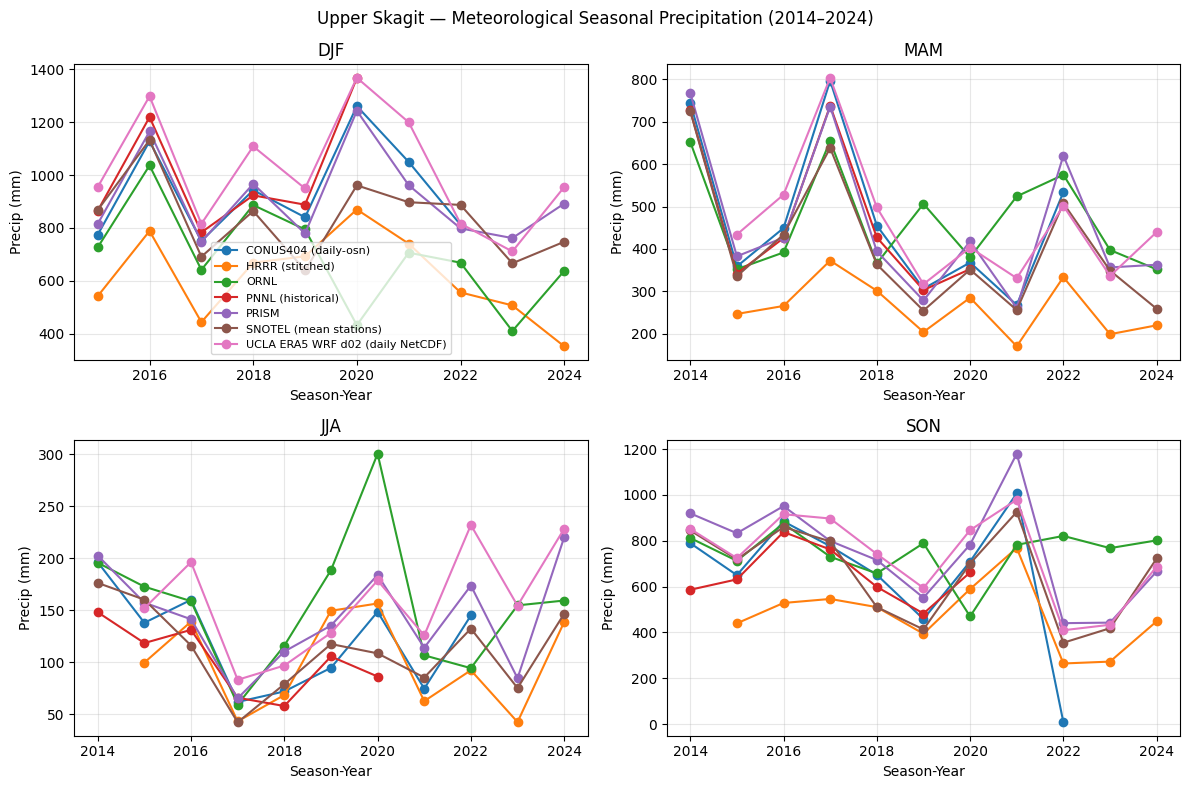

Saved plot → /data0/balaji24/data/derived/met_season_precip_Sauk_2014_2024.png


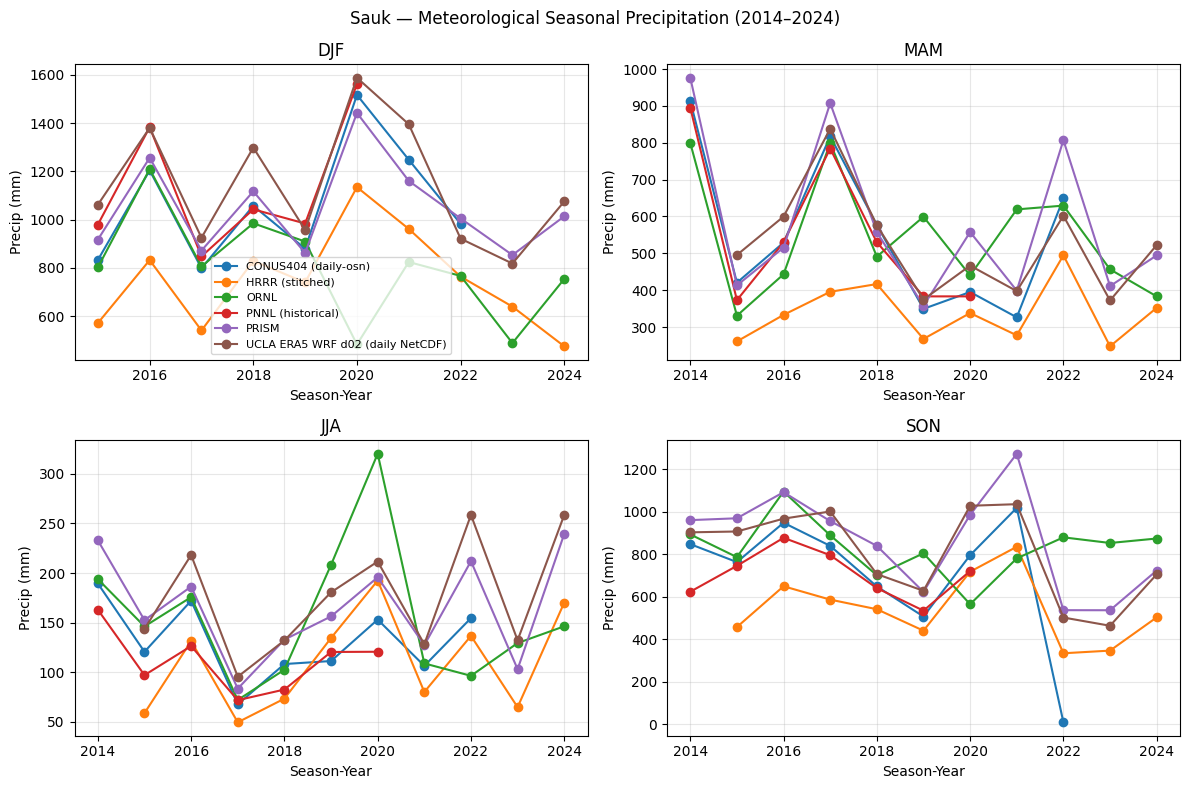

Saved plot → /data0/balaji24/data/derived/met_season_precip_Lower_Skagit_2014_2024.png


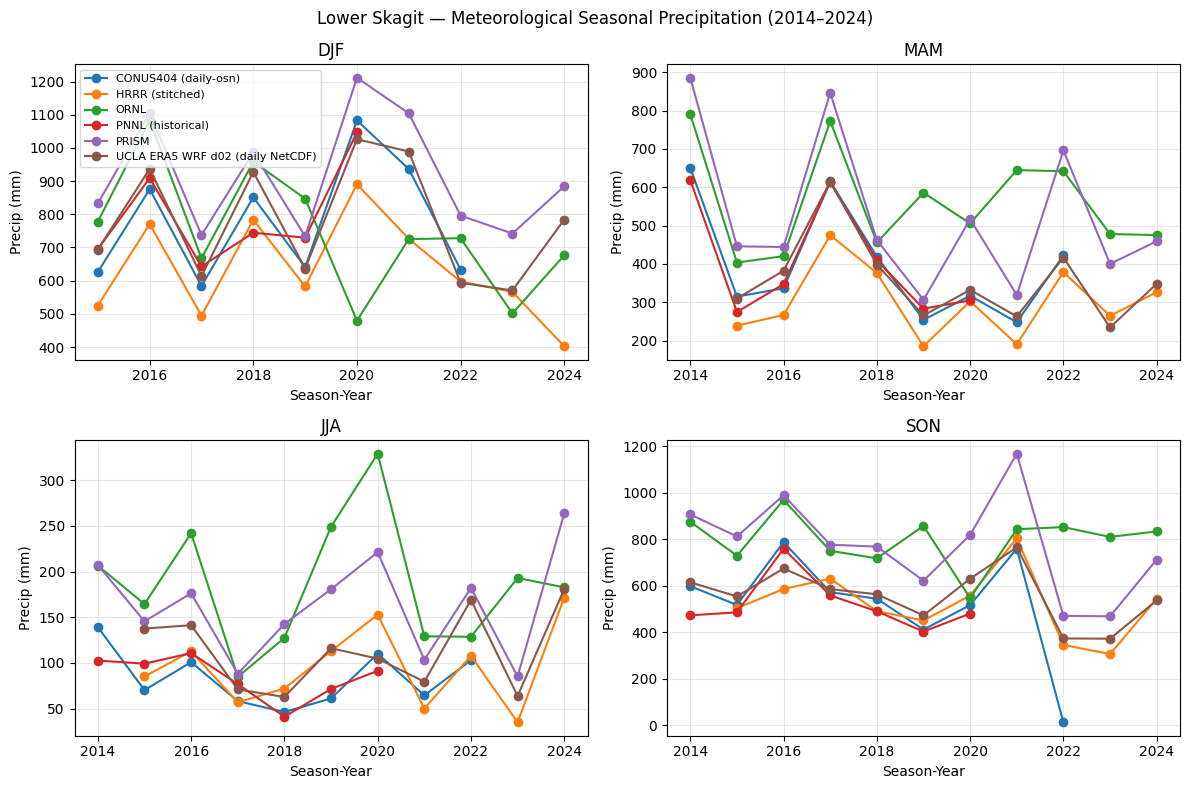

Saved seasonal-sum plot → /data0/balaji24/data/derived/met_season_precip_skagit_regions_2014_2024_ALL.png


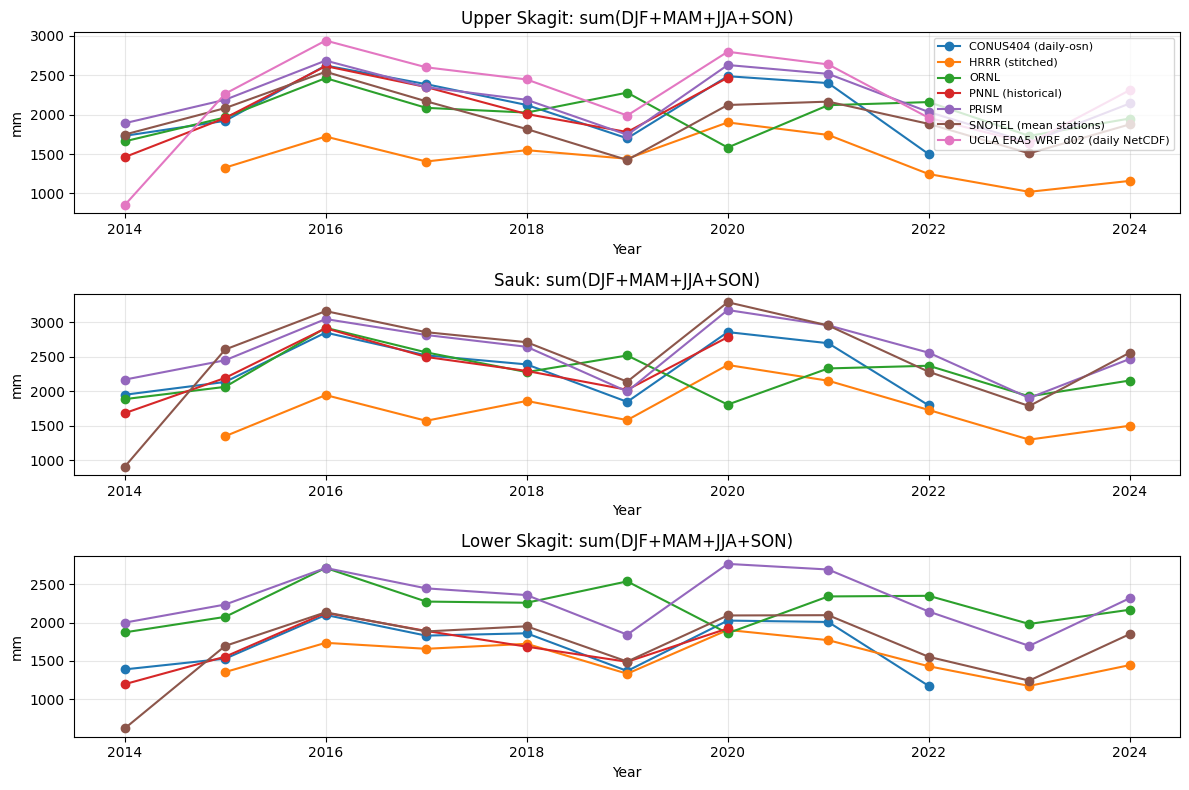


[MAE vs PRISM] Per (region, season, year) (mm):
           region season  year                           dataset      mae_mm
0    Lower Skagit    DJF  2015              CONUS404 (daily-osn)  206.415408
1    Lower Skagit    DJF  2015                   HRRR (stitched)  307.533104
2    Lower Skagit    DJF  2015                              ORNL   54.887326
3    Lower Skagit    DJF  2015                 PNNL (historical)  137.646914
4    Lower Skagit    DJF  2015            SNOTEL (mean stations)         NaN
..            ...    ...   ...                               ...         ...
769  Upper Skagit    SON  2024                   HRRR (stitched)  217.481896
770  Upper Skagit    SON  2024                              ORNL  135.705257
771  Upper Skagit    SON  2024                 PNNL (historical)         NaN
772  Upper Skagit    SON  2024            SNOTEL (mean stations)   56.636730
773  Upper Skagit    SON  2024  UCLA ERA5 WRF d02 (daily NetCDF)   21.272656

[774 rows x 5 columns]
Sav

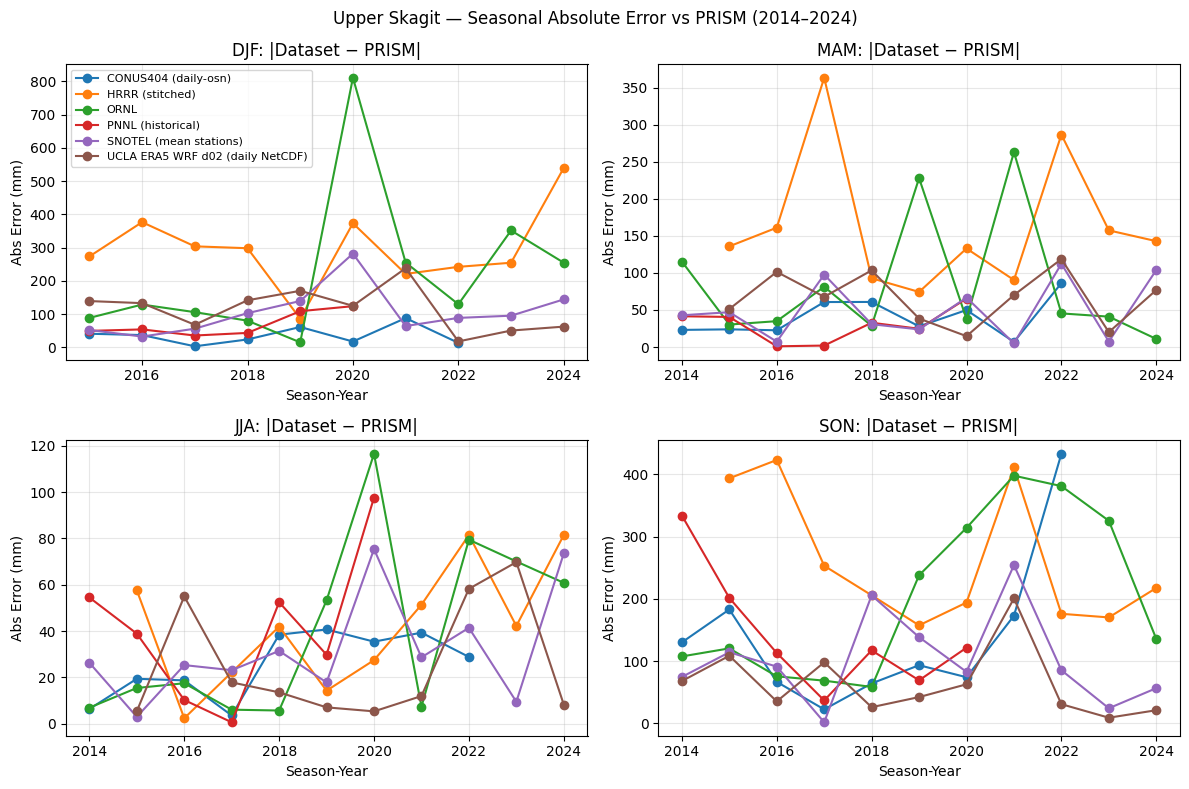

Saved MAE plot → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_Sauk_2014_2024.png


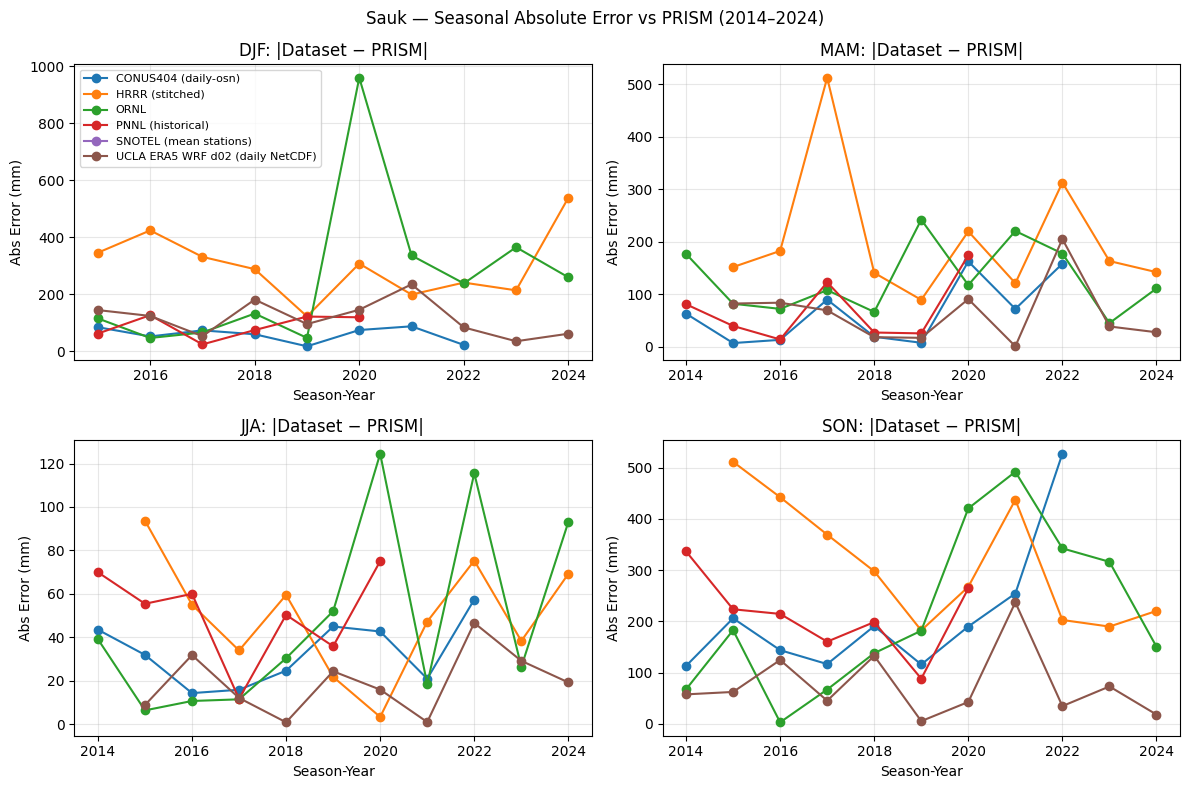

Saved MAE plot → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_Lower_Skagit_2014_2024.png


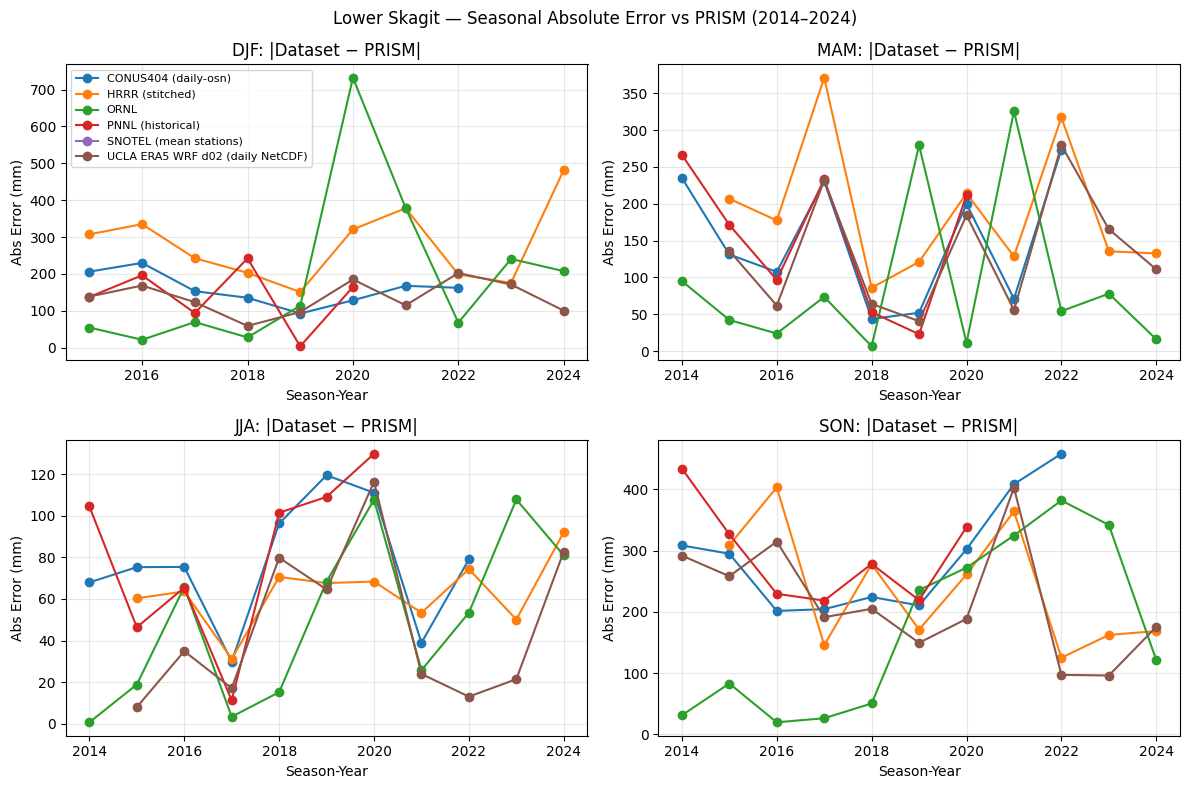

Saved MAE summary plot → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_skagit_regions_2014_2024.png


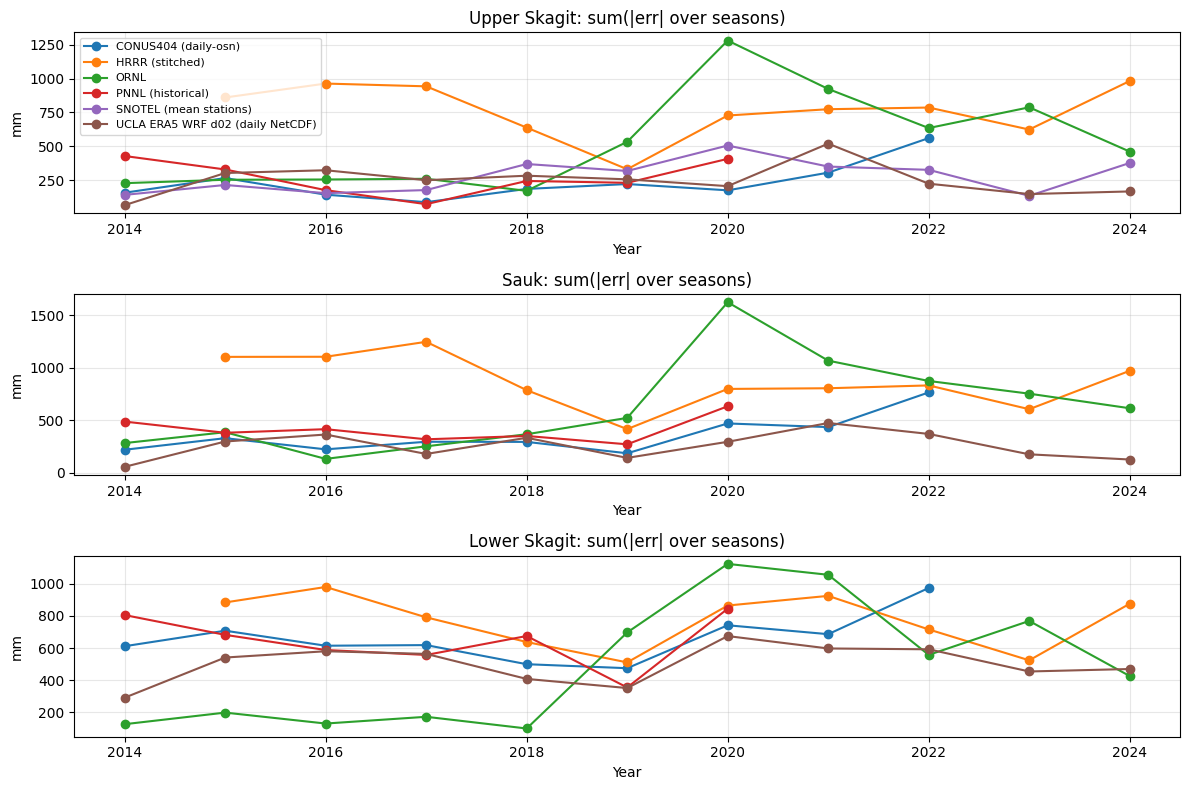

In [ ]:
# ============================
# Skagit Basin — METEOROLOGICAL SEASON Precip (mm) by dataset (DJF/MAM/JJA/SON)
# NOW BY 3 REGIONS (HUC8-dominant sub-basins):
#   - Upper Skagit
#   - Sauk
#   - Lower Skagit
#
# Safe, de-accumulating where needed, robust to duplicates
#
# METEOROLOGICAL SEASONS:
#   - DJF = Dec(previous year) + Jan/Feb(current year)  labeled by ending year
#   - MAM = Mar/Apr/May (year)
#   - JJA = Jun/Jul/Aug (year)
#   - SON = Sep/Oct/Nov (year)
#
# ADD:
# - Per-(region,season,year) absolute error (|err|) vs PRISM for all other datasets
#
#
# Fixed:
# - DJF 2014 requires Dec 2013, which many products don't have.
#   For FAIR & COMPLETE comparison, compute/plot DJF from 2015 onward.
#   (MAM/JJA/SON still start at 2014.)
#
# - Ensure DJF grouping coordinate is explicitly named "year"
#   so ann.sel(year=...) works (ORNL/PRISM/CONUS404 were silently skipped before).
# ============================

import json, re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2024   # season-year labels (DJF labeled by ending year)

# dataset roots
P_ORNL_DIR   = BASE / "ornl"
P_PRISM_DIR  = BASE / "prism_ppt"
P_HRRR_DIR   = BASE / "weather_data"             # many YYYY-MM_HRRR_data.zarr
P_WRF_DIR    = BASE / "ucla_wrf_outputs"         # yearly zarrs (not used in this version)
PNNL_HIST    = BASE / "PNNL" / "historical"      # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

# outputs
CSV_OUT = OUT / f"met_season_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"
PNG_OUT = OUT / f"met_season_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.png"

MAE_REF = "PRISM"
MAE_CSV_OUT = OUT / f"met_season_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.csv"
MAE_PNG_OUT = OUT / f"met_season_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.png"

# 3-region definition (dominant HUC8s inside Skagit)
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# ---------------- MET SEASON helpers ----------------
SEASONS = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}

# --- DJF needs Dec(prev year), so DJF 2014 requires Dec 2013 (often missing).
# For fair comparison across datasets, start DJF from YEAR_MIN+1.
def years_for_season(season_label: str):
    if season_label == "DJF":
        return range(YEAR_MIN + 1, YEAR_MAX + 1)
    return range(YEAR_MIN, YEAR_MAX + 1)

def keep_year(season_label: str, yr: int) -> bool:
    return yr in years_for_season(season_label)

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

# ---- plotting helper: convert 0 to NaN ONLY for plotting ----
def plot_nozero_line(ax, x, y, *, marker="o", label=None):
    """Matplotlib line plot that hides zeros by converting them to NaN."""
    if hasattr(y, "where"):
        y_plot = y.where(y != 0)
    else:
        y_plot = np.where(np.asarray(y) != 0, y, np.nan)
    ax.plot(x, y_plot, marker=marker, label=label)

# ---------------- Region handling ----------------
def load_regions_gdf():
    """Load the 3 dominant HUC8 polygons, clipped to Skagit boundary."""
    import geopandas as gpd

    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if huc8_3.empty:
        raise ValueError(
            f"No matching HUC8 regions found for {REGION_NAMES}. "
            f"Check HUC8_GEO path and the 'Name' field values."
        )

    # clip each HUC8 polygon to Skagit boundary (ensures no outside slivers)
    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    # preserve desired order
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def _to_2d(arr):
    """Take a lat/lon-like array and reduce it to 2D (y,x) or (lat,lon)."""
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def region_mean(da, grid_ds=None, regions_gdf=None):
    """
    Mean(da) inside each region polygon.
    Returns DataArray with an added 'region' dimension.
    """
    if regions_gdf is None:
        raise ValueError("regions_gdf is required for region_mean")

    try:
        import regionmask
    except Exception as e:
        raise RuntimeError(f"regionmask is required for region_mean: {e}")

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        out = da
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    lat_name, lon_name = find_lat_lon_names(host)
    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(host[lon_name])
    lat = _to_2d(host[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )

    rid = regs.mask(lon, lat)

    out_list = []
    for i, rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

# ---------------- Season aggregation ----------------
def season_year_index(time_da, season_label):
    """
    DJF labeled by ending year (Dec - y+1). Others labeled by calendar year.
    IMPORTANT: ensure returned coordinate is named 'year' so groupby dim is stable.
    """
    y = time_da.dt.year
    m = time_da.dt.month
    if season_label == "DJF":
        sy = xr.where(m == 12, y + 1, y)
    else:
        sy = y
    return sy.rename("year")  

def seasonal_sum_mm(da, season_label):
    """
    Sum over a meteorological season grouped by season-year.
    Works for da with dims like ('time', 'region') or ('time',).
    Returns dims: ('year', 'region') or ('year',)
    """
    if "time" not in da.dims:
        return None
    da = ensure_time_sorted_unique(da)
    months = SEASONS[season_label]
    da_s = da.where(da["time"].dt.month.isin(months), drop=True)
    if da_s.sizes.get("time", 0) == 0:
        return None

    sy = season_year_index(da_s["time"], season_label)  # now named 'year'
    out = da_s.groupby(sy).sum("time", skipna=True)

    # some xarray versions still create a dim with sy.name; enforce rename to 'year'
    if "year" not in out.dims:
        candidates = [d for d in out.dims if d not in ("time", "region")]
        if candidates:
            out = out.rename({candidates[0]: "year"})

    out.name = "mm"
    return out

def pick_year(ann, year):
    """Robustly extract a given year scalar from ann."""
    if ann is None:
        return np.nan
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=year).values)
        # fallback: if a coord/dim has 'year' in name
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: year}).values)
        for d in ann.dims:
            if "year" in str(d):
                return float(ann.sel({d: year}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

def season_time_window(year, season_label):
    """Return ISO start/end strings (inclusive slice) for season-year."""
    def month_end(y, m):
        return (pd.Timestamp(y, m, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

    if season_label == "DJF":
        start = pd.Timestamp(year - 1, 12, 1).strftime("%Y-%m-%d")
        end   = month_end(year, 2)
        return start, end
    if season_label == "MAM":
        return f"{year}-03-01", month_end(year, 5)
    if season_label == "JJA":
        return f"{year}-06-01", month_end(year, 8)
    if season_label == "SON":
        return f"{year}-09-01", month_end(year, 11)
    raise ValueError(season_label)

# --------- HRRR robust deaccumulation ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    run_coord = next((c for c in ("run", "init", "forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step", "lead", "forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)

    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

def hrrr_month_prefixes_for_season_year(year: int, season_label: str):
    if season_label == "DJF":
        return {f"{year-1}-12", f"{year}-01", f"{year}-02"}
    if season_label == "MAM":
        return {f"{year}-03", f"{year}-04", f"{year}-05"}
    if season_label == "JJA":
        return {f"{year}-06", f"{year}-07", f"{year}-08"}
    if season_label == "SON":
        return {f"{year}-09", f"{year}-10", f"{year}-11"}
    raise ValueError(season_label)

# ---------------- Collectors ----------------
regions_gdf = load_regions_gdf()
rows = []

GLOBAL_START = f"{YEAR_MIN-1}-12-01"
GLOBAL_END   = (pd.Timestamp(YEAR_MAX, 11, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

# ---------- ORNL ----------
if P_ORNL_DIR.exists():
    ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if ornl_years:
        dso = xr.concat(
            [safe_open_zarr(p) for p in ornl_years],
            dim="time", join="outer", coords="minimal", compat="override"
        )
        if "prcp" in dso:
            da = ensure_time_sorted_unique(dso["prcp"])
            rm = region_mean(da, grid_ds=dso, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))

            for s in SEASONS.keys():
                ann = seasonal_sum_mm(rm, s)  # dims: (year, region)
                if ann is None:
                    continue
                for yr in years_for_season(s):
                    for rname in ann["region"].values:
                        try:
                            val = float(ann.sel(year=yr, region=rname).values)
                        except Exception:
                            val = np.nan
                        if np.isfinite(val):
                            rows.append({"dataset": "ORNL", "region": str(rname), "season": s, "year": int(yr), "mm": float(val)})

# ---------- PRISM ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time", join="outer", coords="minimal", compat="override"
        )
        v = next((vv for vv in ["ppt", "precip", "prcp"] if vv in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])
            rm = region_mean(da, grid_ds=dsp, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))

            for s in SEASONS.keys():
                ann = seasonal_sum_mm(rm, s)  # dims: (year, region)
                if ann is None:
                    continue
                for yr in years_for_season(s):
                    for rname in ann["region"].values:
                        try:
                            val = float(ann.sel(year=yr, region=rname).values)
                        except Exception:
                            val = np.nan
                        if np.isfinite(val):
                            rows.append({"dataset": "PRISM", "region": str(rname), "season": s, "year": int(yr), "mm": float(val)})

# ---------- HRRR ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
available = {p.name[:7] for p in monthly}

if monthly:
    available_prefixes = sorted(list(available))
    print(f"[HRRR] months available: {available_prefixes[0]} … {available_prefixes[-1]} (n={len(available_prefixes)})")

    for s in SEASONS.keys():
        for yr in years_for_season(s):
            need = hrrr_month_prefixes_for_season_year(yr, s)
            missing = sorted(list(need - available))
            if missing:
                print(f"[HRRR] {s} {yr}: missing months {missing} -> skipping")
                continue

            parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])
            ds0 = safe_open_zarr(parts[0])

            var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
            if not var:
                print(f"[HRRR] {s} {yr}: no tp/apcp in {parts[0].name} -> skipping")
                try: ds0.close()
                except Exception: pass
                continue

            dsets = []
            ok = True
            for p in parts:
                dsm = safe_open_zarr(p)
                if var not in dsm:
                    print(f"[HRRR] {s} {yr}: {p.name} missing {var} -> skipping")
                    try: dsm.close()
                    except Exception: pass
                    ok = False
                    break
                dsets.append(dsm[[var]])

            if not ok:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

            hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
            if hourly_mm.sizes.get("time", 0) == 0:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            daily = hourly_mm.resample(time="1D").sum()
            rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
            rm_daily = ensure_time_sorted_unique(rm_daily)

            t0, t1 = season_time_window(yr, s)
            rm_daily = rm_daily.sel(time=slice(t0, t1))
            if rm_daily.sizes.get("time", 0) == 0:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            season_tot = rm_daily.sum("time", skipna=True)
            for rname in season_tot["region"].values:
                val = float(season_tot.sel(region=rname).values)
                if np.isfinite(val):
                    rows.append({"dataset": "HRRR (stitched)", "region": str(rname), "season": s, "year": int(yr), "mm": float(val)})

            print(f"[HRRR] {s} {yr}: " + ", ".join([f"{r}={float(season_tot.sel(region=r)):.1f}" for r in season_tot["region"].values]))

            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
else:
    print("[HRRR] No HRRR monthly zarrs found -> skipping HRRR.")

# ---------- UCLA ERA5 WRF d02 (daily NetCDF) ----------
UCLA_DATASET_NAME = "UCLA ERA5 WRF d02 (daily NetCDF)"
UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

def pick_time_dim(da):
    if "time" in da.dims: return "time"
    if "day" in da.dims: return "day"
    for d in da.dims:
        if "time" in d.lower() or "day" in d.lower():
            return d
    raise ValueError(f"[UCLA] No time-like dim found. dims={da.dims}")

def ensure_sorted_unique_time(da, tdim="time"):
    da = da.sortby(tdim)
    try:
        t = pd.to_datetime(da[tdim].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel({tdim: np.sort(idx)})
    except Exception:
        pass
    return da

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    # Sep..Dec belong to label=year; Jan..Aug belong to label=year-1
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets, pr_list = [], []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue

        pr = ds["prec"]
        tdim = pick_time_dim(pr)
        if tdim != "time":
            pr = pr.rename({tdim: "time"})

        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = ensure_sorted_unique_time(pr_all, "time")
    pr_all = pr_all.sel(time=slice(t0, t1))

    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

def build_ucla_region_masks(coord_file: Path, regions_gdf):
    import shapely
    try:
        from shapely import contains_xy
        has_contains_xy = True
    except Exception:
        has_contains_xy = False
        from shapely.prepared import prep

    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    masks = {}
    for _, row in regions_gdf.iterrows():
        name = str(row["Name"])
        geom = row["geometry"]

        if has_contains_xy:
            m_flat = contains_xy(geom, lonv, latv)
        else:
            pg = prep(geom)
            m_flat = np.array([pg.contains(shapely.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)

        mask2d = m_flat.reshape(ny, nx).astype("float32")
        masks[name] = xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)
        print(f"[UCLA MASK] {name}: {int(mask2d.sum())} cells inside (of {mask2d.size})")

    return masks

def masked_mean_timeseries(pr: xr.DataArray, mask2d: xr.DataArray) -> xr.DataArray:
    tdim = "time"
    spatial_dims = [d for d in pr.dims if d != tdim]

    mask = mask2d
    if set(mask.dims) != set(spatial_dims):
        rename_map = {}
        for md in mask.dims:
            for pdim in spatial_dims:
                if mask.sizes[md] == pr.sizes[pdim]:
                    rename_map[md] = pdim
                    break
        mask = mask.rename(rename_map)

    denom = mask.sum(dim=spatial_dims, skipna=True)
    if float(denom.values) == 0.0:
        return xr.full_like(pr.isel({tdim: 0}), np.nan).expand_dims({tdim: pr[tdim]})

    pr = pr.chunk({tdim: min(366, pr.sizes[tdim])})
    num = (pr * mask).sum(dim=spatial_dims, skipna=True)
    return num / denom

if UCLA_PREC_DIR.exists() and UCLA_COORD_FILE.exists():
    UCLA_REGION_MASKS = build_ucla_region_masks(UCLA_COORD_FILE, regions_gdf)

    for s in SEASONS.keys():
        for yr in years_for_season(s):
            t0, t1 = season_time_window(yr, s)

            pr, parents = open_ucla_prec_for_window(t0, t1)
            if pr is None:
                continue

            try:
                for rname in REGION_NAMES:
                    mask = UCLA_REGION_MASKS.get(rname)
                    if mask is None:
                        continue

                    ts = masked_mean_timeseries(pr, mask)
                    val = float(ts.sum(dim="time", skipna=True).compute().values)

                    if np.isfinite(val):
                        rows.append({
                            "dataset": UCLA_DATASET_NAME,
                            "region": str(rname),
                            "season": s,
                            "year": int(yr),
                            "mm": float(val),
                        })
            finally:
                for ds in parents:
                    try: ds.close()
                    except Exception: pass
else:
    print("[UCLA] Missing UCLA precip dir or coord file -> skipping UCLA.")

# ---------- SNOTEL ----------
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        skagit_geom = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326").geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
        if not skagit_stations.empty and "name" in skagit_stations.columns:
            skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            regs = regions_gdf.copy().to_crs("EPSG:4326")
            skagit_stations = skagit_stations.to_crs("EPSG:4326")

            try:
                joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name":"region"}), predicate="within", how="left")
            except TypeError:
                joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name":"region"}), op="within", how="left")

            joined = joined.dropna(subset=["region"])
            if joined.empty:
                print("[SNOTEL] Stations found but none fall within the 3 regions -> skipping.")
            else:
                print("[SNOTEL] Using stations by region:")
                for region in REGION_NAMES:
                    sub = joined[joined["region"] == region]
                    if sub.empty:
                        continue
                    names = sub["name"].tolist() if "name" in sub.columns else sub["code"].tolist()
                    print(f"  - {region}: {names}")

                base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"
                seasonal_values = {}  # (region, season, year) list of station totals

                for _, row in joined.iterrows():
                    code = row.get("code")
                    name = row.get("name", code)
                    region = row["region"]
                    if pd.isna(code):
                        continue

                    csv_url = f"{base_csv_url}/{code}.csv"
                    try:
                        df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                    except Exception as e:
                        print(f"[SNOTEL] Failed to read {code} ({name}): {e}")
                        continue

                    if "PRCPSA" not in df_s.columns:
                        print(f"[SNOTEL] No PRCPSA for {code} ({name}), skipping.")
                        continue

                    precip_mm = (df_s["PRCPSA"] * 1000.0).loc[GLOBAL_START:GLOBAL_END]
                    idx = precip_mm.index

                    month = idx.month.to_numpy()
                    year_arr = idx.year.to_numpy()

                    season = np.full(len(idx), "", dtype=object)
                    season[np.isin(month, [12, 1, 2])] = "DJF"
                    season[np.isin(month, [3, 4, 5])] = "MAM"
                    season[np.isin(month, [6, 7, 8])] = "JJA"
                    season[np.isin(month, [9, 10, 11])] = "SON"

                    season_year = year_arr.copy()
                    dec_mask = (season == "DJF") & (month == 12)
                    season_year[dec_mask] = season_year[dec_mask] + 1

                    tmp = pd.DataFrame({"mm": precip_mm.values, "season": season, "year": season_year}, index=idx)
                    tmp = tmp[tmp["season"].isin(SEASONS.keys())]

                    # Apply per-season year validity (DJF starts at YEAR_MIN+1)
                    tmp = tmp[tmp.apply(lambda r: keep_year(r["season"], int(r["year"])), axis=1)]

                    agg = tmp.groupby(["season", "year"])["mm"].sum()
                    for (ss, yy), val in agg.items():
                        seasonal_values.setdefault((region, ss, int(yy)), []).append(float(val))

                for (region, ss, yy), vals in seasonal_values.items():
                    rows.append({
                        "dataset": "SNOTEL (mean stations)",
                        "region": str(region),
                        "season": ss,
                        "year": int(yy),
                        "mm": float(np.nanmean(vals))
                    })

# ---------- PNNL (historical) ----------
PNNL_REGION_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")

def expected_months_for_season(season_label: str):
    return set(SEASONS[season_label])

def months_present_in_selection(time_values):
    t = pd.to_datetime(time_values)
    return set(pd.Index(t.month).unique().tolist())

def years_needed_for_season(season_label: str, yr: int):
    return {yr - 1, yr} if season_label == "DJF" else {yr}

if PNNL_HIST.exists() and PNNL_REGION_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_REGION_MASK)
    if "mask" not in mask_ds:
        raise ValueError("[PNNL] Expected variable 'mask' in PNNL_REGION_MASK")
    if "region" not in mask_ds["mask"].dims:
        raise ValueError("[PNNL] Expected 'mask' to have a 'region' dimension")

    region_labels = [str(r) for r in mask_ds["region"].values]

    print("[PNNL] Starting seasonal regional ingest (strict months, scalar-only)...")

    for s in SEASONS.keys():
        need_months = expected_months_for_season(s)

        for yr in years_for_season(s):
            t0, t1 = season_time_window(yr, s)

            files = []
            for yy in sorted(years_needed_for_season(s, yr)):
                files += sorted(glob(str(PNNL_HIST / f"{yy}" / "*PREC_ACC_NC*.nc")))
            files = sorted(files)

            if not files:
                continue

            def _preprocess(ds):
                keep = [v for v in ds.data_vars if "PREC_ACC_NC" in v]
                return ds[keep] if keep else ds

            dsp = xr.open_mfdataset(
                files,
                combine="by_coords",
                engine="netcdf4",
                parallel=False,
                preprocess=_preprocess,
                chunks={"time": 24 * 7},
            )

            v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
            if v is None:
                dsp.close()
                continue

            p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(t0, t1))
            if p.sizes.get("time", 0) == 0:
                dsp.close()
                continue

            seen_months = months_present_in_selection(p["time"].values)
            missing_months = sorted(list(need_months - set(seen_months)))
            if missing_months:
                print(f"[PNNL] SKIP {s} {yr}: missing months {missing_months} (seen={sorted(list(seen_months))})")
                dsp.close()
                continue

            P = p.sum(dim="time", skipna=True)

            spatial_dims = [d for d in P.dims if d != "time"]
            if len(spatial_dims) != 2:
                dsp.close()
                raise ValueError(f"[PNNL] Unexpected spatial dims for {v}: {P.dims}")

            for rname in region_labels:
                mr = mask_ds["mask"].sel(region=rname)

                if set(mr.dims) != set(spatial_dims):
                    mr = mr.rename({mr.dims[0]: spatial_dims[0], mr.dims[1]: spatial_dims[1]})

                val = P.where(mr).mean(dim=spatial_dims, skipna=True).compute()
                mm = float(val.values)

                if np.isfinite(mm):
                    rows.append({
                        "dataset": "PNNL (historical)",
                        "region": str(rname),
                        "season": s,
                        "year": int(yr),
                        "mm": float(mm),
                    })

            dsp.close()

    mask_ds.close()
else:
    if PNNL_HIST.exists():
        print("[PNNL] Skipping regional PNNL: missing region mask file:", PNNL_REGION_MASK)

# ---------- CONUS404 ----------
try:
    import intake
    import geopandas as gpd  # noqa: F401
    import shapely
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(GLOBAL_START, GLOBAL_END))

        lat = ds["lat"]
        lon = ds["lon"]

        regs = regions_gdf.to_crs("EPSG:4326")

        for region in REGION_NAMES:
            geom = regs.loc[regs["Name"] == region, "geometry"].iloc[0]
            mask_np = shapely.contains_xy(geom, lon.values, lat.values)
            mask_da = xr.DataArray(mask_np, dims=("y", "x"))

            region_daily = precip.where(mask_da).mean(dim=("y", "x"))

            for s in SEASONS.keys():
                ann = seasonal_sum_mm(region_daily, s)
                if ann is None:
                    continue
                for yr in years_for_season(s):
                    val = pick_year(ann, yr)
                    if np.isfinite(val):
                        rows.append({
                            "dataset": "CONUS404 (daily-osn)",
                            "region": region,
                            "season": s,
                            "year": int(yr),
                            "mm": float(val),
                        })

# ---------------- Results ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "region", "season", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["region", "dataset", "season", "year"])
      .reset_index(drop=True)
)

print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# ---------------- Plotting ----------------
seasons_order = ["DJF","MAM","JJA","SON"]

# One figure per region (cleanest)
for region in REGION_NAMES:
    df_r = df[df["region"] == region]
    if df_r.empty:
        continue

    fig = plt.figure(figsize=(12, 8))
    for i, s in enumerate(seasons_order, start=1):
        ax = plt.subplot(2, 2, i)
        dss = df_r[df_r["season"] == s]
        for name, g in dss.groupby("dataset"):
            g_plot = g.assign(mm=g["mm"].where(g["mm"] != 0))
            ax.plot(g_plot["year"], g_plot["mm"], marker="o", label=name)

        ax.set_title(s)
        ax.set_xlabel("Season-Year")
        ax.set_ylabel("Precip (mm)")
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.legend(fontsize=8)

    fig.suptitle(f"{region} — Meteorological Seasonal Precipitation ({YEAR_MIN}–{YEAR_MAX})", y=0.98)
    fig.tight_layout()
    out_png = OUT / f"met_season_precip_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.savefig(out_png, dpi=160)
    print("Saved plot →", out_png)
    plt.show()

# Combined PNG summary: total annualized seasonal sum (sum over seasons) by dataset.
summary = df.groupby(["region", "dataset", "year"], as_index=False)["mm"].sum()
fig = plt.figure(figsize=(12, 8))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = summary[summary["region"] == region]
    for name, g in sub.groupby("dataset"):
        g_plot = g.assign(mm=g["mm"].where(g["mm"] != 0))
        ax.plot(g_plot["year"], g_plot["mm"], marker="o", label=name)

    ax.set_title(f"{region}: sum(DJF+MAM+JJA+SON)")
    ax.set_xlabel("Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(PNG_OUT, dpi=160)
print("Saved seasonal-sum plot →", PNG_OUT)
plt.show()

# ==========================================================
# Per-(region,season,year) absolute error vs PRISM
# ==========================================================
wide = df.pivot_table(index=["region", "season", "year"], columns="dataset", values="mm", aggfunc="first")

if MAE_REF not in wide.columns:
    raise ValueError(f"[MAE] Reference dataset '{MAE_REF}' not found. Available: {list(wide.columns)}")

abs_err = (wide.sub(wide[MAE_REF], axis=0)).abs()
abs_err = abs_err.drop(columns=[MAE_REF], errors="ignore")

mae_long = (
    abs_err.reset_index()
           .melt(id_vars=["region", "season", "year"], var_name="dataset", value_name="mae_mm")
           .sort_values(["region", "season", "year", "dataset"])
           .reset_index(drop=True)
)

print("\n[MAE vs PRISM] Per (region, season, year) (mm):")
print(mae_long)

mae_long.to_csv(MAE_CSV_OUT, index=False)
print("Saved MAE CSV →", MAE_CSV_OUT)

# Plot MAE: one figure per region (4 panels)
for region in REGION_NAMES:
    try:
        abs_r = abs_err.xs(region, level="region")
    except Exception:
        continue

    fig = plt.figure(figsize=(12, 8))
    for i, s in enumerate(seasons_order, start=1):
        ax = plt.subplot(2, 2, i)
        if s not in abs_r.index.get_level_values("season"):
            ax.set_title(f"{s} (no data)")
            ax.grid(True, alpha=0.3)
            continue

        sub = abs_r.xs(s, level="season")  # index: year
        for dsname in sub.columns:
            ax.plot(sub.index, sub[dsname].where(sub[dsname] != 0), marker="o", label=dsname)

        ax.set_title(f"{s}: |Dataset − {MAE_REF}|")
        ax.set_xlabel("Season-Year")
        ax.set_ylabel("Abs Error (mm)")
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.legend(fontsize=8)

    fig.suptitle(f"{region} — Seasonal Absolute Error vs {MAE_REF} ({YEAR_MIN}–{YEAR_MAX})", y=0.98)
    fig.tight_layout()
    out_png = OUT / f"met_season_mae_vs_{MAE_REF}_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.savefig(out_png, dpi=160)
    print("Saved MAE plot →", out_png)
    plt.show()

# Save a combined MAE summary plot: sum over seasons of abs error by dataset
mae_sum = mae_long.groupby(["region", "dataset", "year"], as_index=False)["mae_mm"].sum()
fig = plt.figure(figsize=(12, 8))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = mae_sum[mae_sum["region"] == region]
    for name, g in sub.groupby("dataset"):
        g_plot = g.assign(mae_mm=g["mae_mm"].where(g["mae_mm"] != 0))
        ax.plot(g_plot["year"], g_plot["mae_mm"], marker="o", label=name)

    ax.set_title(f"{region}: sum(|err| over seasons)")
    ax.set_xlabel("Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(MAE_PNG_OUT, dpi=160)
print("Saved MAE summary plot →", MAE_PNG_OUT)
plt.show()

# ORNL Fix

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76e51d98f830>


[DAYMET-PC] DJF 2015: Upper Skagit=726.5, Sauk=805.7, Lower Skagit=764.9, Full Skagit=749.5
[DAYMET-PC] DJF 2016: Upper Skagit=1036.5, Sauk=1213.2, Lower Skagit=1071.2, Full Skagit=1081.9
[DAYMET-PC] DJF 2017: Upper Skagit=640.4, Sauk=806.2, Lower Skagit=654.3, Full Skagit=680.9
[DAYMET-PC] DJF 2018: Upper Skagit=886.6, Sauk=992.2, Lower Skagit=946.0, Full Skagit=918.3
[DAYMET-PC] DJF 2019: Upper Skagit=701.5, Sauk=769.9, Lower Skagit=670.0, Full Skagit=713.8
[DAYMET-PC] DJF 2020: Upper Skagit=1112.8, Sauk=1342.1, Lower Skagit=1146.1, Full Skagit=1170.4
[DAYMET-PC] DJF 2021: Upper Skagit=263.3, Sauk=331.4, Lower Skagit=340.5, Full Skagit=288.2
[DAYMET-PC] DJF 2022: Upper Skagit=0.0, Sauk=0.0, Lower Skagit=0.0, Full Skagit=0.0
[DAYMET-PC] DJF 2023: Upper Skagit=0.0, Sauk=0.0, Lower Skagit=0.0, Full Skagit=0.0
[DAYMET-PC] DJF 2024: Upper Skagit=0.0, Sauk=0.0, Lower Skagit=0.0, Full Skagit=0.0
[DAYMET-PC] MAM 2014: Upper Skagit=652.5, Sauk=807.7, Lower Skagit=783.3, Full Skagit=704.1
[DAY

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76e4fdf70260>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76e50a3dd040>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76e51d9e44d0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76e5dc4b8f20>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76e509f754f0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76e5e4255790>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76e5d46de180>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76e4fe051ac0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76e509f746e0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76e4fe1ec890>
Unclosed client session
client_session: 

[DAYMET-PC] MAM 2024: Upper Skagit=0.0, Sauk=0.0, Lower Skagit=0.0, Full Skagit=0.0


Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed

...

[HRRR f06] SON 2023: Upper Skagit=320.0, Sauk=386.3, Lower Skagit=344.9, Full Skagit=338.1


/tmp/ipykernel_102400/2824953708.py:297: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  out = xr.concat(out_list, dim="region")


[HRRR f06] SON 2024: Upper Skagit=486.7, Sauk=521.3, Lower Skagit=538.5, Full Skagit=500.1


/tmp/ipykernel_102400/2824953708.py:297: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  out = xr.concat(out_list, dim="region")


                              dataset        region season  year           mm
0                CONUS404 (daily-osn)   Full Skagit    DJF  2015   770.340393
1                CONUS404 (daily-osn)   Full Skagit    DJF  2016  1115.977539
2                CONUS404 (daily-osn)   Full Skagit    DJF  2017   742.075562
3                CONUS404 (daily-osn)   Full Skagit    DJF  2018   959.176514
4                CONUS404 (daily-osn)   Full Skagit    DJF  2019   825.670410
..                                ...           ...    ...   ...          ...
982  UCLA ERA5 WRF d02 (daily NetCDF)  Upper Skagit    SON  2020   846.465576
983  UCLA ERA5 WRF d02 (daily NetCDF)  Upper Skagit    SON  2021   979.396362
984  UCLA ERA5 WRF d02 (daily NetCDF)  Upper Skagit    SON  2022   409.429504
985  UCLA ERA5 WRF d02 (daily NetCDF)  Upper Skagit    SON  2023   433.504700
986  UCLA ERA5 WRF d02 (daily NetCDF)  Upper Skagit    SON  2024   687.385925

[987 rows x 5 columns]
Saved CSV → /data0/balaji24/data/derived

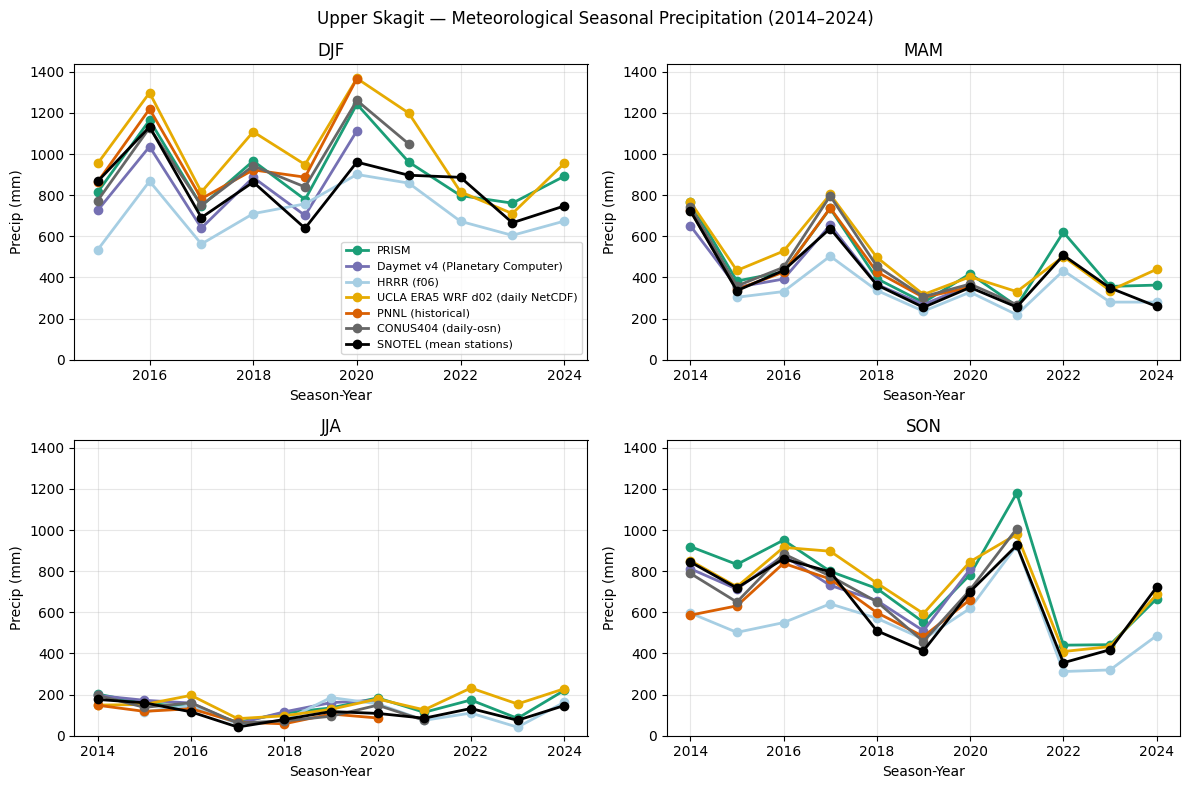

Saved plot → /data0/balaji24/data/derived/met_season_precip_Sauk_2014_2024.png


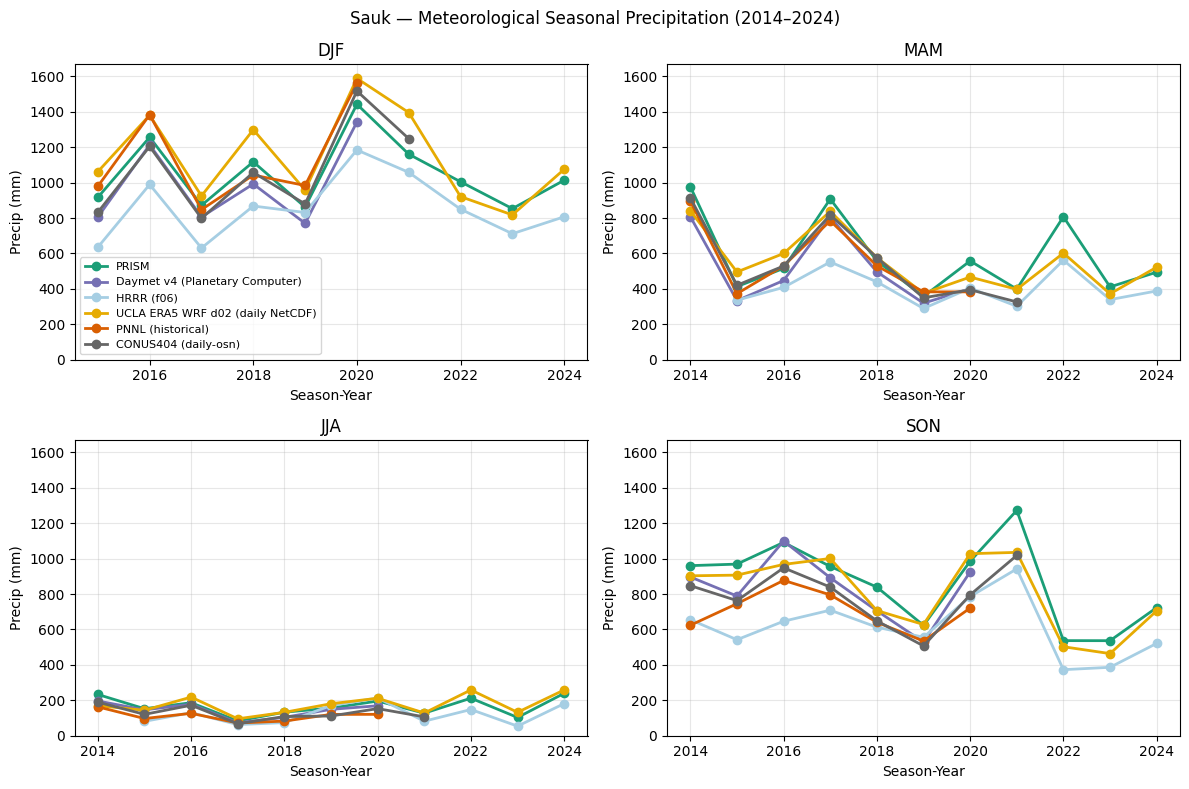

Saved plot → /data0/balaji24/data/derived/met_season_precip_Lower_Skagit_2014_2024.png


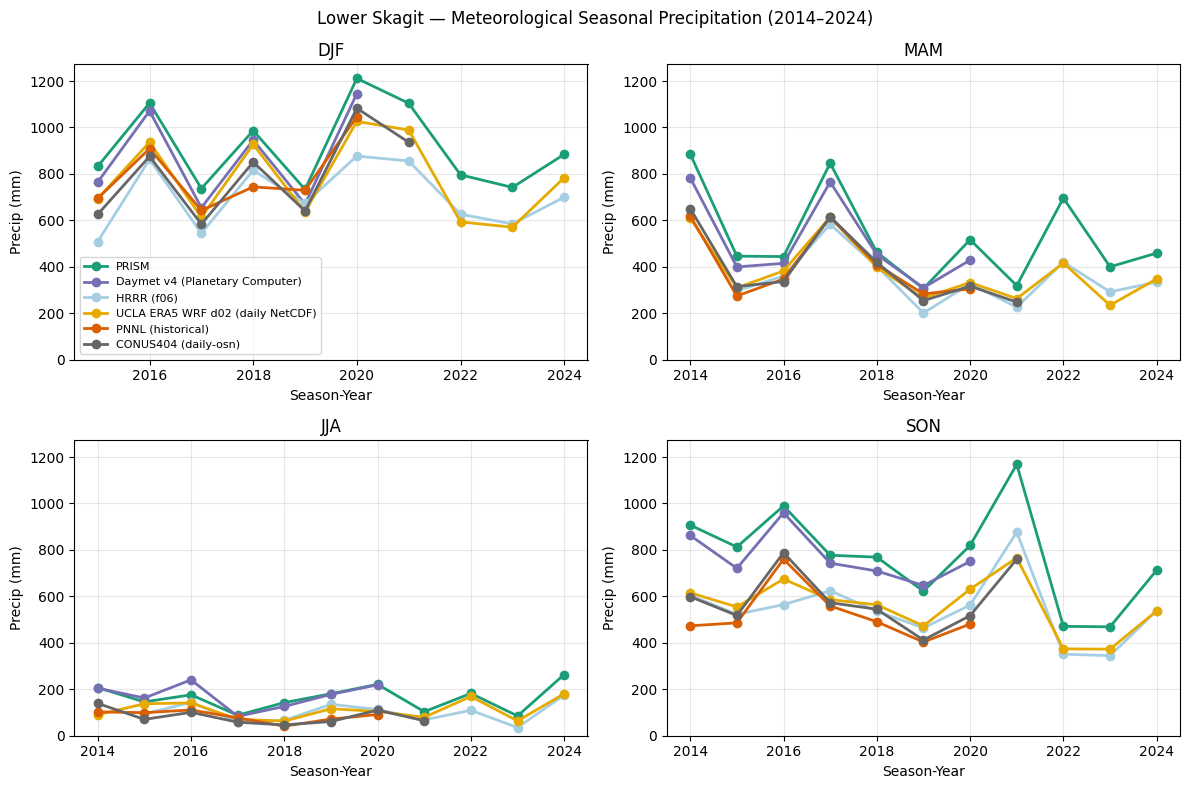

Saved plot → /data0/balaji24/data/derived/met_season_precip_Full_Skagit_2014_2024.png


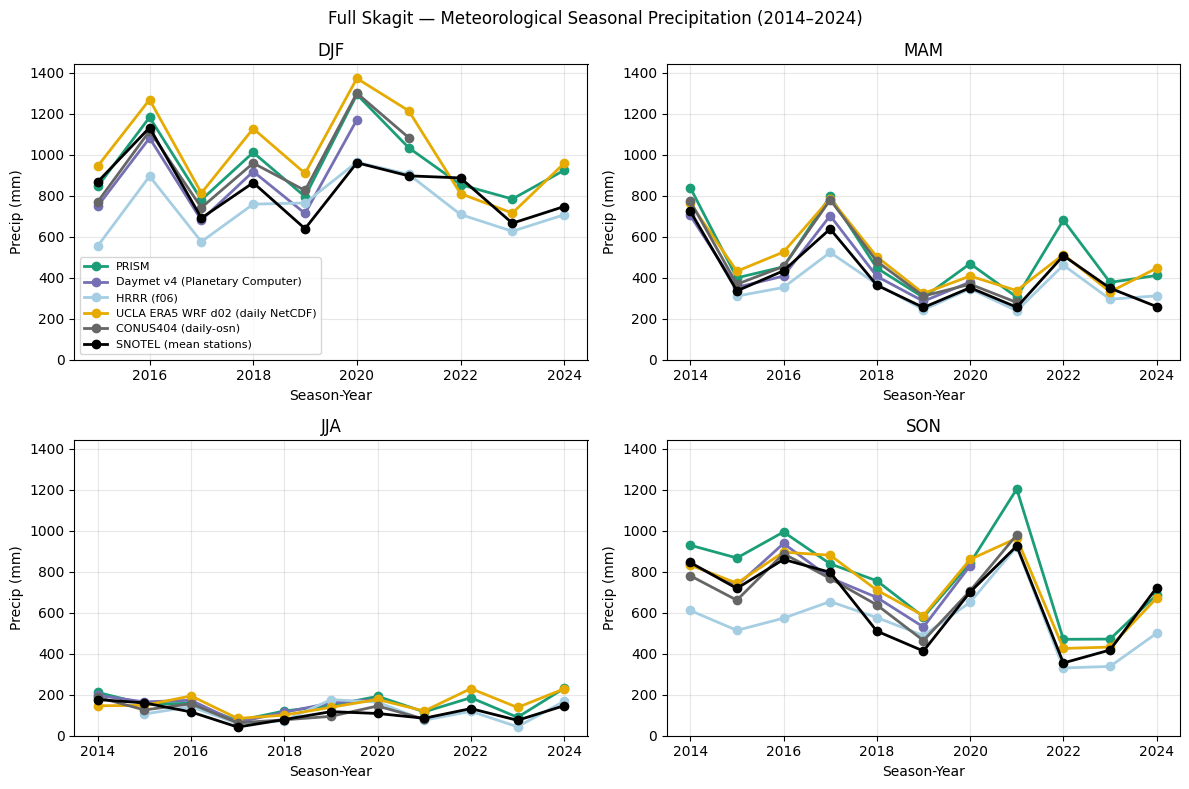

Saved seasonal-sum plot → /data0/balaji24/data/derived/met_season_precip_skagit_regions_2014_2024_ALL.png


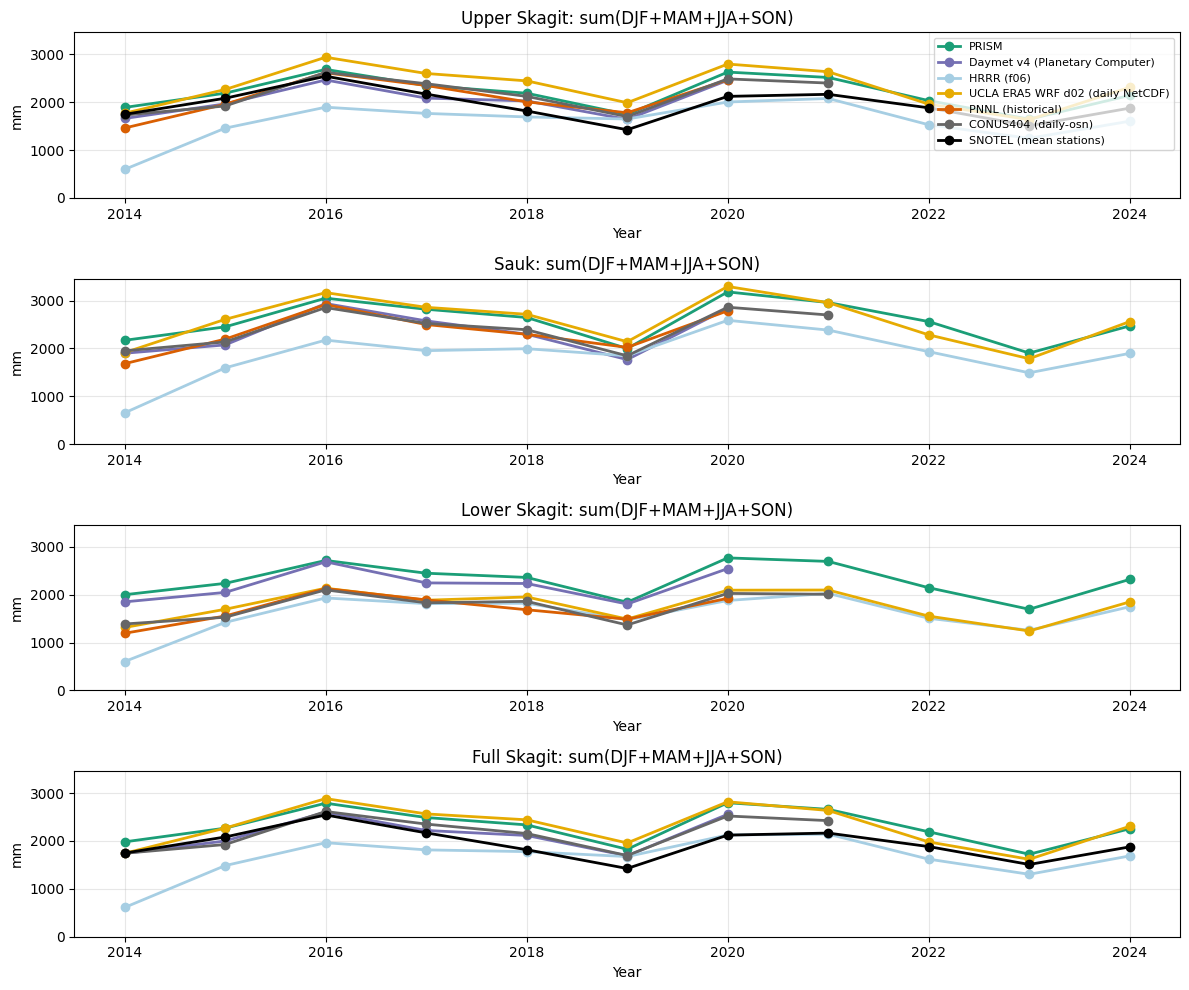


[MAE vs PRISM] Per (region, season, year) (mm):
            region season  year                           dataset      mae_mm
0      Full Skagit    DJF  2015              CONUS404 (daily-osn)   75.281368
1      Full Skagit    DJF  2015    Daymet v4 (Planetary Computer)   96.155818
2      Full Skagit    DJF  2015                        HRRR (f06)  290.679040
3      Full Skagit    DJF  2015                 PNNL (historical)         NaN
4      Full Skagit    DJF  2015            SNOTEL (mean stations)   22.078239
...            ...    ...   ...                               ...         ...
1027  Upper Skagit    SON  2024    Daymet v4 (Planetary Computer)  666.113270
1028  Upper Skagit    SON  2024                        HRRR (f06)  179.446771
1029  Upper Skagit    SON  2024                 PNNL (historical)         NaN
1030  Upper Skagit    SON  2024            SNOTEL (mean stations)   56.636730
1031  Upper Skagit    SON  2024  UCLA ERA5 WRF d02 (daily NetCDF)   21.272656

[1032 rows x 5

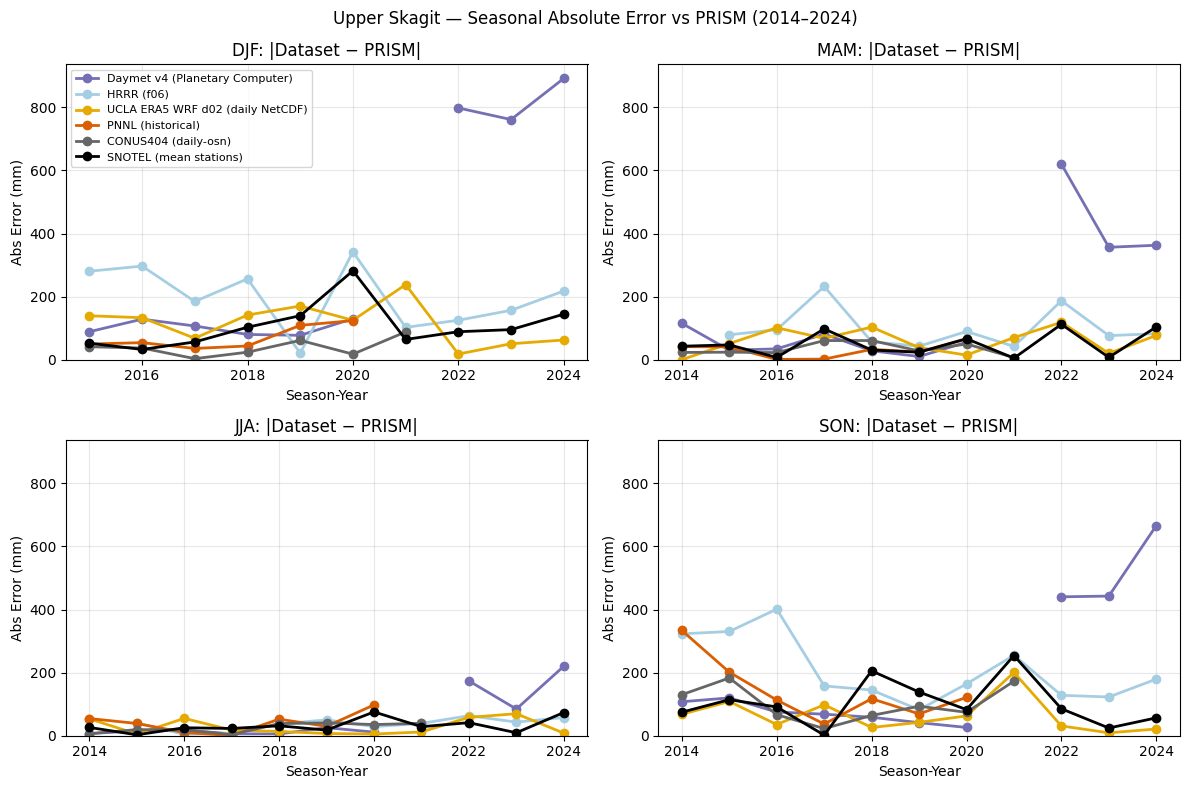

Saved MAE plot → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_Sauk_2014_2024.png


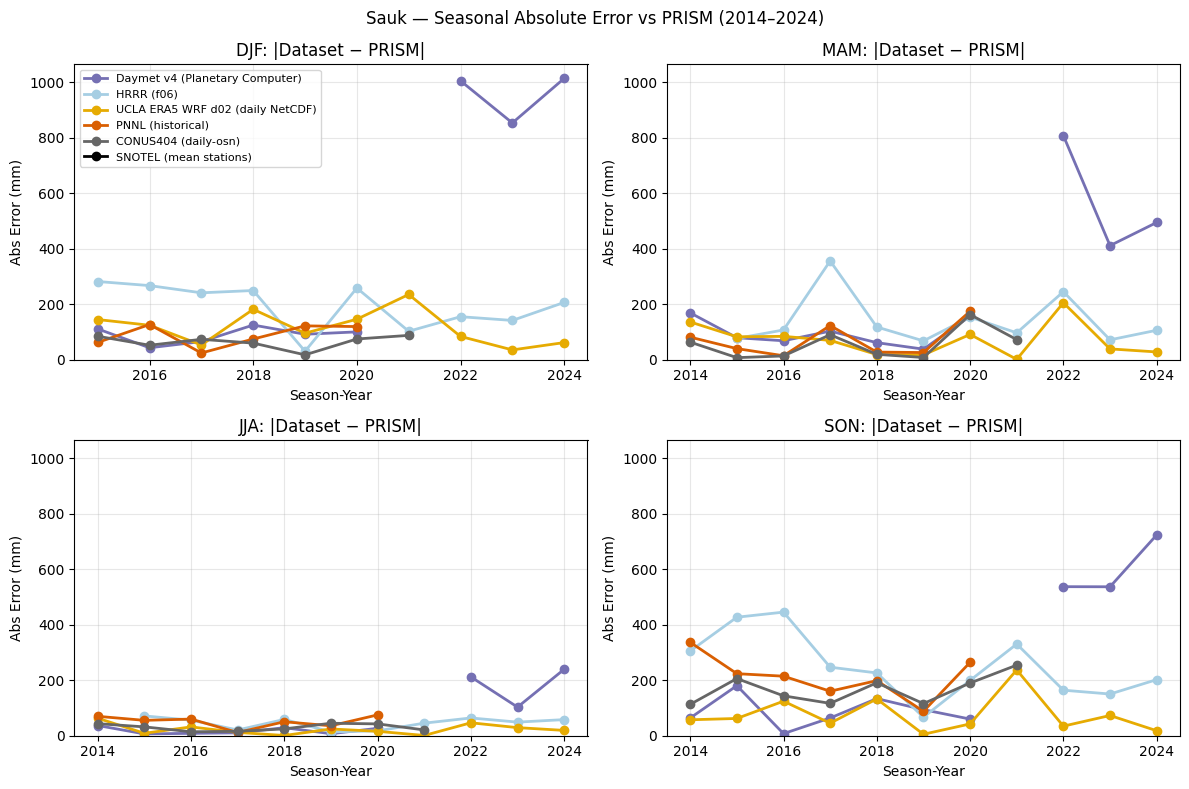

Saved MAE plot → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_Lower_Skagit_2014_2024.png


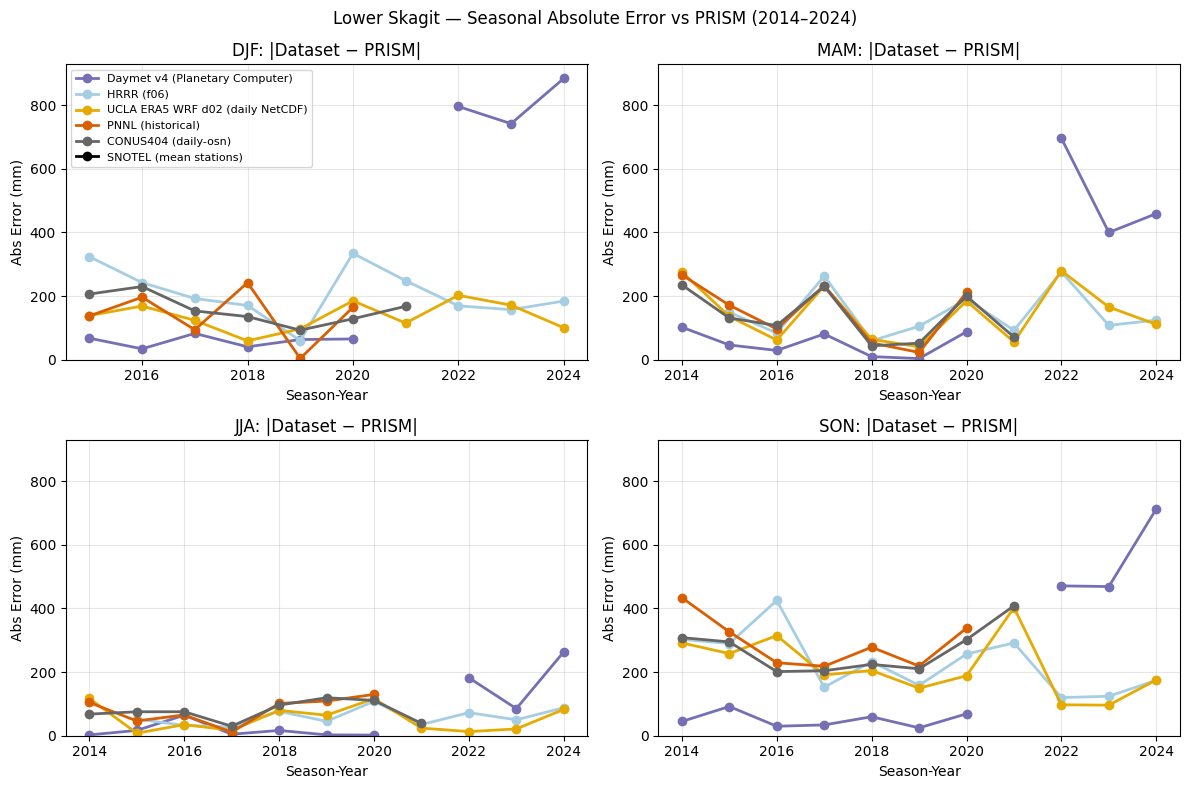

Saved MAE plot → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_Full_Skagit_2014_2024.png


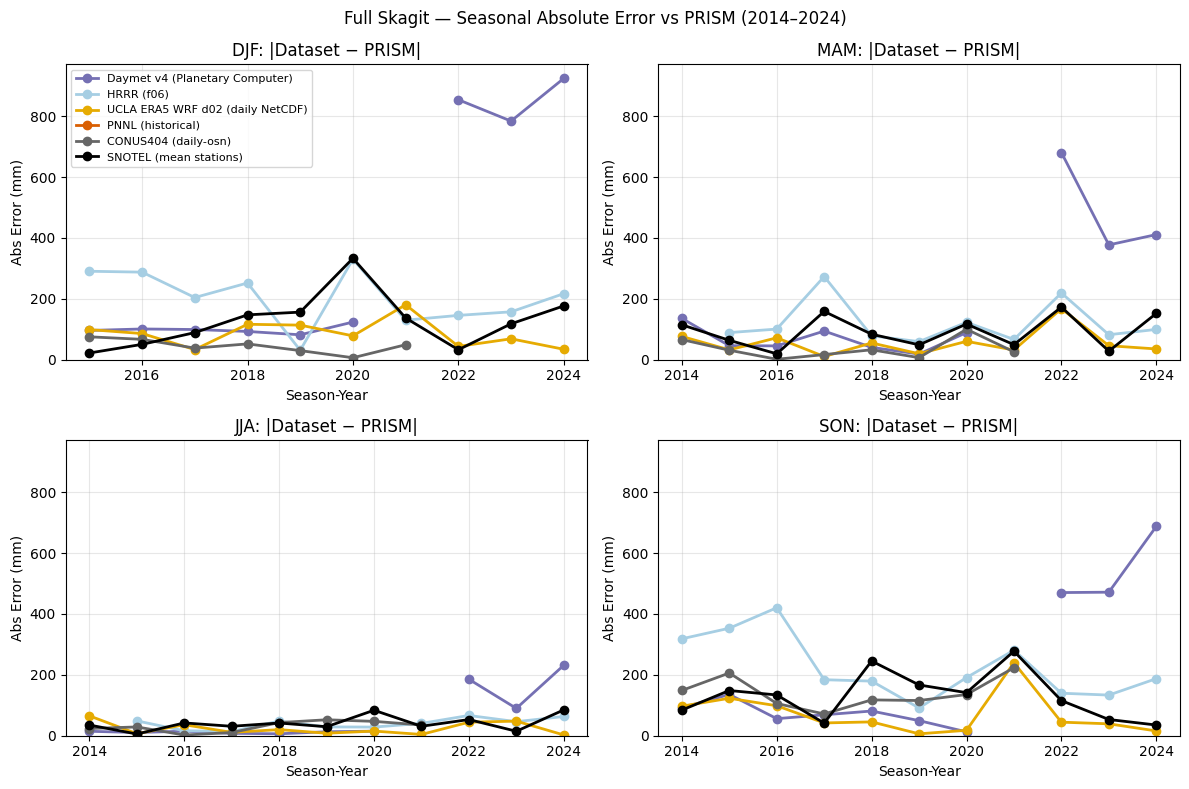

Saved MAE summary plot → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_skagit_regions_2014_2024.png


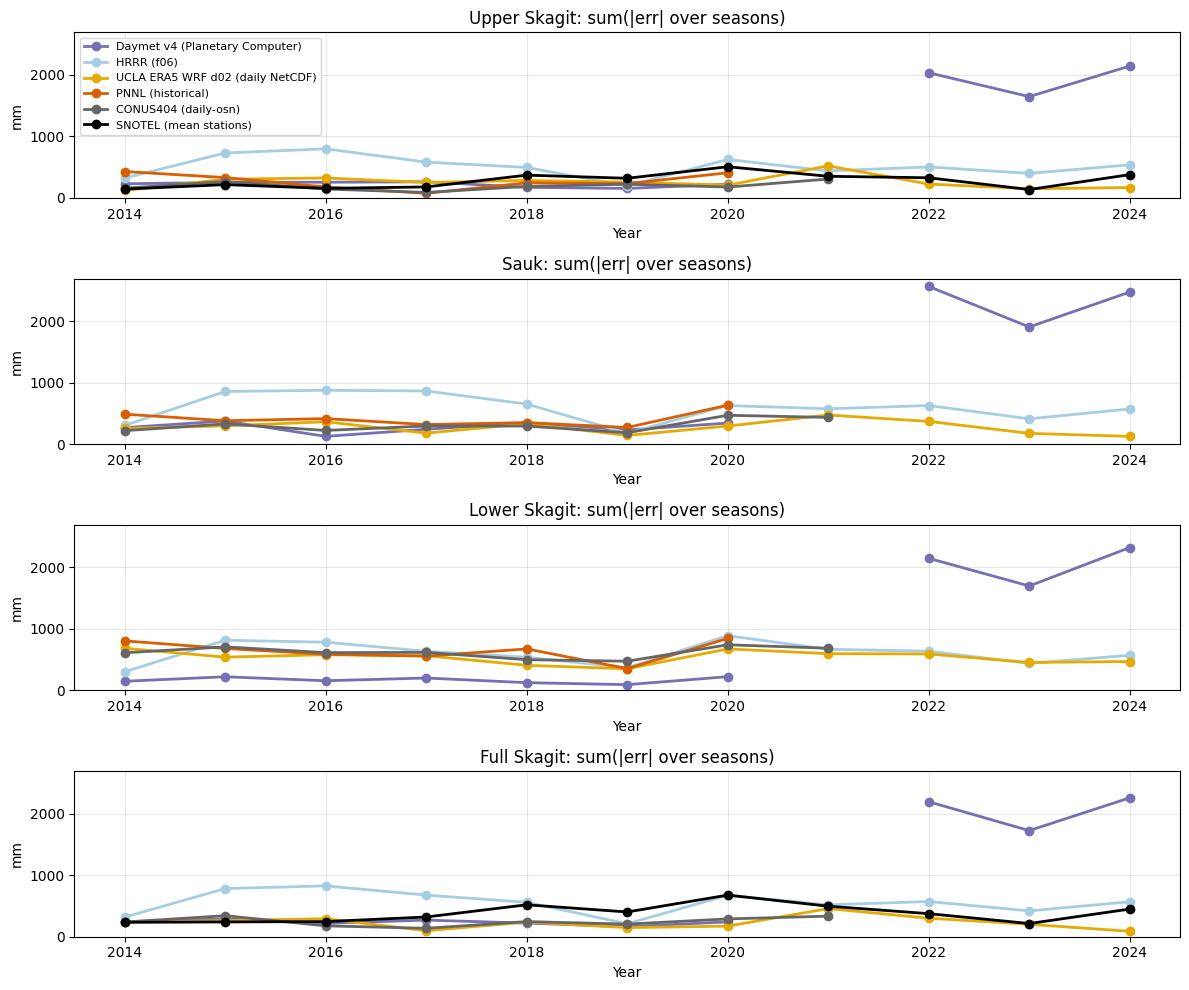

In [ ]:
# ============================
# Skagit Basin — METEOROLOGICAL SEASON Precip (mm) by dataset (DJF/MAM/JJA/SON)
# NOW BY 4 REGIONS:
#   - Upper Skagit
#   - Sauk
#   - Lower Skagit
#   - Full Skagit
#
# Safe, de-accumulating where needed, robust to duplicates
#
# METEOROLOGICAL SEASONS:
#   - DJF = Dec(previous year) + Jan/Feb(current year)   labeled by ending year
#   - MAM = Mar/Apr/May (year)
#   - JJA = Jun/Jul/Aug (year)
#   - SON = Sep/Oct/Nov (year)
#
# Added:
# - Per-(region,season,year) absolute error (|err|) vs PRISM for all other datasets
#
#
# Fixed:
# - DJF 2014 requires Dec 2013, which many products don't have.
#   For FAIR & COMPLETE comparison, compute/plot DJF from 2015 onward.
#   (MAM/JJA/SON still start at 2014.)
#
# - Ensure DJF grouping coordinate is explicitly named "year"
#   so ann.sel(year=...) works
#
#
#
# HRRR CHANGE:
#   - Replace old HRRR logic with the SAME HRRR f06 logic as your WY script:
#       * Uses HRRR f06 zarrs: YYYY-MM_HRRR_f06_data.zarr
#       * tp is 6-hour accumulation for valid time = init + 6h
#       * Keep only init hours 00/06/12/18
#       * Shift time +6h to valid time
#       * Daily totals = sum of the 4 six-hour windows per day
# ============================

import json, re
from pathlib import Path
from glob import glob
import sys, time
from urllib.parse import urlparse, urlunparse

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import shapely

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2024   # season-year labels (DJF labeled by ending year)

# dataset roots
P_PRISM_DIR  = BASE / "prism_ppt"
P_HRRR_DIR   = BASE / "weather_data_06"          # HRRR f06 zarrs: YYYY-MM_HRRR_f06_data.zarr
PNNL_HIST    = BASE / "PNNL" / "historical"      # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

# outputs
CSV_OUT = OUT / f"met_season_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"
PNG_OUT = OUT / f"met_season_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.png"

MAE_REF = "PRISM"
MAE_CSV_OUT = OUT / f"met_season_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.csv"
MAE_PNG_OUT = OUT / f"met_season_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.png"

# Region order for plots
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit", "Full Skagit"]

# ---------------- MET SEASON helpers ----------------
SEASONS = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}

# --- DJF needs Dec(prev year), so DJF 2014 requires Dec 2013 (often missing).
# For fair comparison across datasets, start DJF from YEAR_MIN+1.
def years_for_season(season_label: str):
    if season_label == "DJF":
        return range(YEAR_MIN + 1, YEAR_MAX + 1)
    return range(YEAR_MIN, YEAR_MAX + 1)

def keep_year(season_label: str, yr: int) -> bool:
    return yr in years_for_season(season_label)

# ============================================================
# CANONICAL COLORS (same palette idea as event/WY scripts)
# ============================================================
DATASET_ORDER = [
    "PRISM 4km",
    "PRISM 800m",
    "Daymet-PC",
    "HRRR F01",
    "HRRR F06",
    "UCLA ERA5 d02",
    "PNNL hist",
    "CONUS404",
    "SNOTEL (mean stations)",
]

COLORS = {
    "PRISM 4km":     "#1B9E77",
    "PRISM 800m":    "#66C2A5",
    "Daymet-PC":     "#7570B3",
    "HRRR F01":      "#1F78B4",
    "HRRR F06":      "#A6CEE3",
    "UCLA ERA5 d02": "#E6AB02",
    "PNNL hist":     "#D95F02",
    "CONUS404":      "#666666",
    "SNOTEL (mean stations)": "#000000",
}

def canonical_label(dsname: str) -> str:
    s = str(dsname)

    if s == "PRISM":
        return "PRISM 4km"
    if "Daymet" in s and "Planetary Computer" in s:
        return "Daymet-PC"

    # HRRR
    if s in {"HRRR (f06)", "HRRR f06"}:
        return "HRRR F06"
    if "HRRR" in s and "f06" in s.lower():
        return "HRRR F06"
    if "HRRR" in s and "f01" in s.lower():
        return "HRRR F01"

    if "UCLA" in s and "d02" in s:
        return "UCLA ERA5 d02"
    if s.startswith("PNNL"):
        return "PNNL hist"
    if s.startswith("CONUS404"):
        return "CONUS404"
    if s.startswith("SNOTEL"):
        return "SNOTEL (mean stations)"

    return s

def ordered_datasets_present(names: list[str]) -> list[str]:
    present = list(dict.fromkeys(names))  # stable unique
    ordered = []
    for key in DATASET_ORDER:
        ordered += [d for d in present if canonical_label(d) == key]
    ordered += [d for d in present if d not in ordered]
    return ordered

def color_for(dsname: str) -> str:
    return COLORS.get(canonical_label(dsname), "#000000")

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M","lat2d"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M","lon2d"] if n in ds), None)
    return lat_name, lon_name

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

# ---------------- Region handling ----------------
def load_regions_gdf():
    """
    Load the 3 dominant HUC8 polygons clipped to Skagit boundary + Full Skagit polygon.
    Returns GeoDataFrame with 'Name' and 'geometry' in EPSG:4326.
    """
    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    sub3 = ["Upper Skagit", "Sauk", "Lower Skagit"]
    huc8_3 = huc8[huc8["Name"].isin(sub3)].copy()
    if huc8_3.empty:
        raise ValueError(
            f"No matching HUC8 regions found for {sub3}. "
            f"Check HUC8_GEO path and the 'Name' field values."
        )

    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_3 = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    full_row = gpd.GeoDataFrame(
        {"Name": ["Full Skagit"], "geometry": [skagit_gdf.geometry.iloc[0]]},
        crs="EPSG:4326",
    )

    regions_gdf = pd.concat([regions_3, full_row], ignore_index=True)
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def _to_2d(arr):
    """Take a lat/lon-like array and reduce it to 2D."""
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def region_mean(da, grid_ds=None, regions_gdf=None):
    """
    Mean(da) inside each region polygon using regionmask.
    Returns DataArray with a 'region' dimension.
    """
    if regions_gdf is None:
        raise ValueError("regions_gdf is required for region_mean")

    try:
        import regionmask
    except Exception as e:
        raise RuntimeError(f"regionmask is required for region_mean: {e}")

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        out = da
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    lat_name, lon_name = find_lat_lon_names(host)
    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(host[lon_name])
    lat = _to_2d(host[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_regions",
        overlap=True,
    )

    m3 = regs.mask_3D(lon, lat)

    spatial_dims = [d for d in da.dims if d != time_dim]
    mask_spatial_dims = [d for d in m3.dims if d != "region"]

    if set(mask_spatial_dims) != set(spatial_dims):
        rename_map = {}
        for md in mask_spatial_dims:
            for pdim in spatial_dims:
                if m3.sizes[md] == da.sizes[pdim]:
                    rename_map[md] = pdim
                    break
        if rename_map:
            m3 = m3.rename(rename_map)

    out_list = []
    for i, _rname in enumerate(regs.names):
        m = m3.isel(region=i)
        w = xr.where(m, 1.0, np.nan)
        num = (da * w).mean(dim=spatial_dims, skipna=True)
        out_list.append(num)

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

# ---------------- Season aggregation ----------------
def season_year_index(time_da, season_label):
    """
    DJF labeled by ending year (Dec -> y+1). Others labeled by calendar year.
    IMPORTANT: returned coord is named 'year' so ann.sel(year=...) works.
    """
    y = time_da.dt.year
    m = time_da.dt.month
    if season_label == "DJF":
        sy = xr.where(m == 12, y + 1, y)
    else:
        sy = y
    return sy.rename("year")

def seasonal_sum_mm(da, season_label):
    """
    Sum over a meteorological season grouped by season-year.
    da dims: ('time', 'region') or ('time',)
    returns dims: ('year', 'region') or ('year',)
    """
    if "time" not in da.dims:
        return None
    da = ensure_time_sorted_unique(da)
    months = SEASONS[season_label]
    da_s = da.where(da["time"].dt.month.isin(months), drop=True)
    if da_s.sizes.get("time", 0) == 0:
        return None

    sy = season_year_index(da_s["time"], season_label)
    out = da_s.groupby(sy).sum("time", skipna=True)

    if "year" not in out.dims:
        candidates = [d for d in out.dims if d not in ("time", "region")]
        if candidates:
            out = out.rename({candidates[0]: "year"})

    out.name = "mm"
    return out

def pick_year(ann, year):
    if ann is None:
        return np.nan
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=year).values)
        return np.nan
    except Exception:
        return np.nan

def season_time_window(year, season_label):
    def month_end(y, m):
        return (pd.Timestamp(y, m, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

    if season_label == "DJF":
        start = pd.Timestamp(year - 1, 12, 1).strftime("%Y-%m-%d")
        end   = month_end(year, 2)
        return start, end
    if season_label == "MAM":
        return f"{year}-03-01", month_end(year, 5)
    if season_label == "JJA":
        return f"{year}-06-01", month_end(year, 8)
    if season_label == "SON":
        return f"{year}-09-01", month_end(year, 11)
    raise ValueError(season_label)

# ==========================================================
# HRRR f06 logic
# ==========================================================
def hrrr_f06_daily_precip_mm(ds: xr.Dataset, var="tp") -> xr.DataArray:
    """
    Correct HRRR f06 logic for tp:
      - ds.time is INIT time
      - keep only init hours 00/06/12/18 (non-overlapping 6h blocks)
      - shift init -> valid time by +6h
      - daily totals = sum of 6h accumulations per day
    """
    if var not in ds:
        raise ValueError(f"[HRRR f06] Missing {var}. vars={list(ds.data_vars)}")

    da = ensure_time_sorted_unique(ds[var])

    t = pd.to_datetime(da["time"].values)
    keep = np.isin(t.hour, [0, 6, 12, 18])
    da = da.sel(time=da["time"].values[keep])

    # shift init -> valid time
    da = da.assign_coords(time=(pd.to_datetime(da["time"].values) + pd.Timedelta(hours=6)))

    # daily totals
    daily = da.resample(time="1D").sum()
    return daily

def hrrr_month_prefixes_for_season_year_f06(year: int, season_label: str):
    if season_label == "DJF":
        return {f"{year-1}-12", f"{year}-01", f"{year}-02"}
    if season_label == "MAM":
        return {f"{year}-03", f"{year}-04", f"{year}-05"}
    if season_label == "JJA":
        return {f"{year}-06", f"{year}-07", f"{year}-08"}
    if season_label == "SON":
        return {f"{year}-09", f"{year}-10", f"{year}-11"}
    raise ValueError(season_label)

def load_hrrr_f06_season_totals(P_HRRR_DIR: Path, regions_gdf, season_label: str, yr: int, rows_out: list):
    monthly = [p for p in sorted(P_HRRR_DIR.glob("*.zarr"))
               if re.match(r"\d{4}-\d{2}_HRRR_f06_data\.zarr", p.name)]
    if not monthly:
        print("[HRRR f06] No HRRR f06 monthly zarrs found -> skipping HRRR f06.")
        return

    available = {p.name[:7] for p in monthly}
    need = hrrr_month_prefixes_for_season_year_f06(yr, season_label)
    missing = sorted(list(need - available))
    if missing:
        print(f"[HRRR f06] {season_label} {yr}: missing months {missing} -> skipping")
        return

    parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])
    ds0 = safe_open_zarr(parts[0])

    var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
    if not var:
        print(f"[HRRR f06] {season_label} {yr}: no tp/apcp in {parts[0].name} -> skipping")
        try: ds0.close()
        except Exception: pass
        return

    dsets = []
    ok = True
    for p in parts:
        dsm = safe_open_zarr(p)
        if var not in dsm:
            print(f"[HRRR f06] {season_label} {yr}: {p.name} missing {var} -> skipping")
            try: dsm.close()
            except Exception: pass
            ok = False
            break
        dsets.append(dsm[[var]])

    if not ok:
        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
        return

    try:
        ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

        # correct f06 daily totals
        daily = hrrr_f06_daily_precip_mm(ds, var=var)

        # restrict to season window
        t0, t1 = season_time_window(yr, season_label)
        daily = ensure_time_sorted_unique(daily).sel(time=slice(t0, t1))
        if daily.sizes.get("time", 0) == 0:
            return

        rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
        rm_daily = ensure_time_sorted_unique(rm_daily)

        season_tot = rm_daily.sum("time", skipna=True)  # region

        for rname in season_tot["region"].values:
            val = float(season_tot.sel(region=rname).values)
            if np.isfinite(val):
                rows_out.append({
                    "dataset": "HRRR (f06)",
                    "region": str(rname),
                    "season": season_label,
                    "year": int(yr),
                    "mm": float(val),
                })

        print(f"[HRRR f06] {season_label} {yr}: " +
              ", ".join([f"{r}={float(season_tot.sel(region=r)):.1f}" for r in season_tot["region"].values]))
    finally:
        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass

# ---------------- Collectors ----------------
regions_gdf = load_regions_gdf()
rows = []

GLOBAL_START = f"{YEAR_MIN-1}-12-01"
GLOBAL_END   = (pd.Timestamp(YEAR_MAX, 11, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

# ==========================================================
# Daymet v4 (Planetary Computer) — MET-SEASON totals by regions
# ==========================================================
def ensure_daymet_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_daymet_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
from fsspec.implementations.http import HTTPFileSystem
from shapely.ops import transform as shp_transform

class SASAppendingHTTPFileSystem(HTTPFileSystem):
    def __init__(self, query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._fixed_query = query.lstrip("?")

    def _with_query(self, url: str) -> str:
        u = urlparse(url)
        q = u.query or self._fixed_query
        return urlunparse((u.scheme, u.netloc, u.path, u.params, q, u.fragment))

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        return super()._open(self._with_query(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_query(url), start=start, end=end, **kwargs)

def get_daymet_mapper():
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")
    asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
    signed = pc.sign(col.assets[asset_key]).href

    u = urlparse(signed)
    base = f"{u.scheme}://{u.netloc}{u.path}"
    query = u.query
    fs = SASAppendingHTTPFileSystem(query)
    return fs.get_mapper(base)

def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

_DAYMET_TFM_LL_TO_XY = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)

def lonlat_to_daymet_xy_bounds(geom_wgs84, pad_m=5000.0):
    minx, miny, maxx, maxy = geom_wgs84.bounds
    corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
    xs, ys = zip(*[_DAYMET_TFM_LL_TO_XY.transform(lon, lat) for lon, lat in corners])
    return (float(min(xs) - pad_m), float(max(xs) + pad_m),
            float(min(ys) - pad_m), float(max(ys) + pad_m))

def _daymet_project_geom_to_xy(geom_ll):
    def _proj(x, y, z=None):
        return _DAYMET_TFM_LL_TO_XY.transform(x, y)
    return shp_transform(_proj, geom_ll)

_DAYMET_MASK_CACHE = {}

def daymet_window_region_total(ds_daymet, t0: str, t1: str, region_name: str, geom_ll):
    xmin, xmax, ymin, ymax = lonlat_to_daymet_xy_bounds(geom_ll, pad_m=5000.0)

    y0 = float(ds_daymet["y"].values[0])
    y1 = float(ds_daymet["y"].values[-1])
    y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

    pr = ds_daymet["prcp"].sel(
        time=slice(t0, t1),
        x=slice(xmin, xmax),
        y=y_slice,
    ).chunk({"time": 92, "y": 256, "x": 256})

    key = (float(pr["x"].values[0]), float(pr["x"].values[-1]),
           float(pr["y"].values[0]), float(pr["y"].values[-1]),
           pr.sizes["x"], pr.sizes["y"], region_name)

    mask = _DAYMET_MASK_CACHE.get(key)
    if mask is None:
        xx, yy = xr.broadcast(pr["x"], pr["y"])  # dims (y,x)
        geom_xy = _daymet_project_geom_to_xy(geom_ll)

        from shapely import contains_xy
        mask_np = contains_xy(geom_xy, np.asarray(xx.values), np.asarray(yy.values))
        mask = xr.DataArray(mask_np, dims=xx.dims, coords=xx.coords)
        _DAYMET_MASK_CACHE[key] = mask

    region_daily = pr.where(mask).mean(dim=("y", "x"), skipna=True)
    return float(region_daily.sum(dim="time", skipna=True).compute().values)

DAYMET_NAME = "Daymet v4 (Planetary Computer)"
regions_ll = regions_gdf.to_crs("EPSG:4326")

for s in SEASONS.keys():
    for yr in years_for_season(s):
        t0, t1 = season_time_window(yr, s)
        totals = {r: np.nan for r in REGION_NAMES}

        for attempt in range(1, 4):
            ds_daymet = None
            try:
                mapper = get_daymet_mapper()
                ds_daymet = xr.open_zarr(mapper, consolidated=True)
                if "prcp" not in ds_daymet:
                    raise RuntimeError("Daymet dataset missing 'prcp'")

                for rname in REGION_NAMES:
                    geom = regions_ll.loc[regions_ll["Name"] == rname, "geometry"].iloc[0]
                    totals[rname] = daymet_window_region_total(ds_daymet, t0, t1, rname, geom)
                break
            except Exception as e:
                print(f"[DAYMET-PC] {s} {yr} attempt {attempt}/3 failed ({type(e).__name__}): {e}")
                time.sleep(5 * attempt)
            finally:
                if ds_daymet is not None:
                    try: ds_daymet.close()
                    except Exception: pass

        msg = ", ".join([f"{r}={totals[r]:.1f}" for r in REGION_NAMES if np.isfinite(totals.get(r, np.nan))])
        print(f"[DAYMET-PC] {s} {yr}: {msg}" if msg else f"[DAYMET-PC] {s} {yr}: (no data)")

        for rname, val in totals.items():
            if np.isfinite(val):
                rows.append({"dataset": DAYMET_NAME, "region": str(rname), "season": s, "year": int(yr), "mm": float(val)})

# ==========================================================
# HRRR f06 — seasonal totals by regions
# ==========================================================
if P_HRRR_DIR.exists():
    monthly = [p for p in sorted(P_HRRR_DIR.glob("*.zarr"))
               if re.match(r"\d{4}-\d{2}_HRRR_f06_data\.zarr", p.name)]
    if monthly:
        available = sorted({p.name[:7] for p in monthly})
        print(f"[HRRR f06] months available: {available[0]} … {available[-1]} (n={len(available)})")
    else:
        print("[HRRR f06] No HRRR f06 monthly zarrs found -> skipping HRRR f06.")

    for s in SEASONS.keys():
        for yr in years_for_season(s):
            load_hrrr_f06_season_totals(P_HRRR_DIR, regions_gdf, s, yr, rows)
else:
    print(f"[HRRR f06] HRRR dir missing: {P_HRRR_DIR} -> skipping HRRR f06.")

# ---------- UCLA ERA5 WRF d02 (daily NetCDF) ----------
UCLA_DATASET_NAME = "UCLA ERA5 WRF d02 (daily NetCDF)"
UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

def pick_time_dim(da):
    if "time" in da.dims: return "time"
    if "day" in da.dims: return "day"
    for d in da.dims:
        if "time" in d.lower() or "day" in d.lower():
            return d
    raise ValueError(f"[UCLA] No time-like dim found. dims={da.dims}")

def ensure_sorted_unique_time(da, tdim="time"):
    da = da.sortby(tdim)
    try:
        t = pd.to_datetime(da[tdim].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel({tdim: np.sort(idx)})
    except Exception:
        pass
    return da

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets, pr_list = [], []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue

        pr = ds["prec"]
        tdim = pick_time_dim(pr)
        if tdim != "time":
            pr = pr.rename({tdim: "time"})

        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = ensure_sorted_unique_time(pr_all, "time")
    pr_all = pr_all.sel(time=slice(t0, t1))

    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

def build_ucla_region_masks(coord_file: Path, regions_gdf):
    try:
        from shapely import contains_xy
        has_contains_xy = True
    except Exception:
        has_contains_xy = False
        from shapely.prepared import prep

    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    masks = {}
    for _, row in regions_gdf.iterrows():
        name = str(row["Name"])
        geom = row["geometry"]

        if has_contains_xy:
            m_flat = contains_xy(geom, lonv, latv)
        else:
            pg = prep(geom)
            m_flat = np.array([pg.contains(shapely.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)

        mask2d = m_flat.reshape(ny, nx).astype("float32")
        masks[name] = xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)

    return masks

def masked_mean_timeseries(pr: xr.DataArray, mask2d: xr.DataArray) -> xr.DataArray:
    tdim = "time"
    spatial_dims = [d for d in pr.dims if d != tdim]

    mask = mask2d
    if set(mask.dims) != set(spatial_dims):
        rename_map = {}
        for md in mask.dims:
            for pdim in spatial_dims:
                if mask.sizes[md] == pr.sizes[pdim]:
                    rename_map[md] = pdim
                    break
        mask = mask.rename(rename_map)

    denom = mask.sum(dim=spatial_dims, skipna=True)
    if float(denom.values) == 0.0:
        return xr.full_like(pr.isel({tdim: 0}), np.nan).expand_dims({tdim: pr[tdim]})

    pr = pr.chunk({tdim: min(366, pr.sizes[tdim])})
    num = (pr * mask).sum(dim=spatial_dims, skipna=True)
    return num / denom

if UCLA_PREC_DIR.exists() and UCLA_COORD_FILE.exists():
    UCLA_REGION_MASKS = build_ucla_region_masks(UCLA_COORD_FILE, regions_gdf)

    for s in SEASONS.keys():
        for yr in years_for_season(s):
            t0, t1 = season_time_window(yr, s)

            pr, parents = open_ucla_prec_for_window(t0, t1)
            if pr is None:
                continue

            try:
                for rname in REGION_NAMES:
                    mask = UCLA_REGION_MASKS.get(rname)
                    if mask is None:
                        continue

                    ts = masked_mean_timeseries(pr, mask)
                    val = float(ts.sum(dim="time", skipna=True).compute().values)

                    if np.isfinite(val):
                        rows.append({"dataset": UCLA_DATASET_NAME, "region": str(rname), "season": s, "year": int(yr), "mm": float(val)})
            finally:
                for ds in parents:
                    try: ds.close()
                    except Exception: pass
else:
    print("[UCLA] Missing UCLA precip dir or coord file -> skipping UCLA.")

# ---------- SNOTEL ----------
try:
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        skagit_geom = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326").geometry.iloc[0]
        skagit_stations = stations[stations.geometry.within(skagit_geom)].copy()

        desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
        if not skagit_stations.empty and "name" in skagit_stations.columns:
            skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"
            station_season_totals = {}

            for _, st in skagit_stations.iterrows():
                code = st.get("code")
                if pd.isna(code):
                    continue

                csv_url = f"{base_csv_url}/{code}.csv"
                try:
                    df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                except Exception:
                    continue

                if "PRCPSA" not in df_s.columns:
                    continue

                precip_mm = (df_s["PRCPSA"] * 1000.0).loc[GLOBAL_START:GLOBAL_END]
                idx = precip_mm.index

                month = idx.month.to_numpy()
                year_arr = idx.year.to_numpy()

                season = np.full(len(idx), "", dtype=object)
                season[np.isin(month, [12, 1, 2])] = "DJF"
                season[np.isin(month, [3, 4, 5])] = "MAM"
                season[np.isin(month, [6, 7, 8])] = "JJA"
                season[np.isin(month, [9, 10, 11])] = "SON"

                season_year = year_arr.copy()
                dec_mask = (season == "DJF") & (month == 12)
                season_year[dec_mask] = season_year[dec_mask] + 1

                tmp = pd.DataFrame({"mm": precip_mm.values, "season": season, "year": season_year}, index=idx)
                tmp = tmp[tmp["season"].isin(SEASONS.keys())]
                tmp = tmp[tmp.apply(lambda r: keep_year(r["season"], int(r["year"])), axis=1)]

                station_season_totals[code] = tmp.groupby(["season", "year"])["mm"].sum()

            if station_season_totals:
                regs3 = regions_gdf[regions_gdf["Name"].isin(["Upper Skagit","Sauk","Lower Skagit"])].copy().to_crs("EPSG:4326")
                skagit_stations = skagit_stations.to_crs("EPSG:4326")

                try:
                    joined = gpd.sjoin(skagit_stations, regs3.rename(columns={"Name":"region"}), predicate="within", how="left")
                except TypeError:
                    joined = gpd.sjoin(skagit_stations, regs3.rename(columns={"Name":"region"}), op="within", how="left")

                sub_joined = joined.dropna(subset=["region"]).copy()
                if not sub_joined.empty:
                    seasonal_values = {}
                    for _, row in sub_joined.iterrows():
                        code = row.get("code")
                        region = row["region"]
                        if pd.isna(code) or code not in station_season_totals:
                            continue
                        for (ss, yy), val in station_season_totals[code].items():
                            seasonal_values.setdefault((region, ss, int(yy)), []).append(float(val))

                    for (region, ss, yy), vals in seasonal_values.items():
                        rows.append({"dataset":"SNOTEL (mean stations)","region":str(region),"season":ss,"year":int(yy),"mm":float(np.nanmean(vals))})

                seasonal_values_full = {}
                for code, agg in station_season_totals.items():
                    for (ss, yy), val in agg.items():
                        seasonal_values_full.setdefault((ss, int(yy)), []).append(float(val))
                for (ss, yy), vals in seasonal_values_full.items():
                    rows.append({"dataset":"SNOTEL (mean stations)","region":"Full Skagit","season":ss,"year":int(yy),"mm":float(np.nanmean(vals))})

# ---------- PNNL (historical) ----------
PNNL_REGION_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")

def expected_months_for_season(season_label: str):
    return set(SEASONS[season_label])

def months_present_in_selection(time_values):
    t = pd.to_datetime(time_values)
    return set(pd.Index(t.month).unique().tolist())

def years_needed_for_season(season_label: str, yr: int):
    return {yr - 1, yr} if season_label == "DJF" else {yr}

if PNNL_HIST.exists() and PNNL_REGION_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_REGION_MASK)
    region_labels = [str(r) for r in mask_ds["region"].values]

    for s in SEASONS.keys():
        need_months = expected_months_for_season(s)

        for yr in years_for_season(s):
            t0, t1 = season_time_window(yr, s)

            files = []
            for yy in sorted(years_needed_for_season(s, yr)):
                files += sorted(glob(str(PNNL_HIST / f"{yy}" / "*PREC_ACC_NC*.nc")))
            files = sorted(files)
            if not files:
                continue

            def _preprocess(ds):
                keep = [v for v in ds.data_vars if "PREC_ACC_NC" in v]
                return ds[keep] if keep else ds

            dsp = xr.open_mfdataset(
                files,
                combine="by_coords",
                engine="netcdf4",
                parallel=False,
                preprocess=_preprocess,
                chunks={"time": 24 * 7},
            )

            v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
            if v is None:
                dsp.close()
                continue

            p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(t0, t1))
            if p.sizes.get("time", 0) == 0:
                dsp.close()
                continue

            seen_months = months_present_in_selection(p["time"].values)
            if need_months - set(seen_months):
                dsp.close()
                continue

            P = p.sum(dim="time", skipna=True)
            spatial_dims = [d for d in P.dims if d != "time"]
            if len(spatial_dims) != 2:
                dsp.close()
                raise ValueError(f"[PNNL] Unexpected spatial dims for {v}: {P.dims}")

            for rname in region_labels:
                mr = mask_ds["mask"].sel(region=rname)
                if set(mr.dims) != set(spatial_dims):
                    mr = mr.rename({mr.dims[0]: spatial_dims[0], mr.dims[1]: spatial_dims[1]})

                val = P.where(mr).mean(dim=spatial_dims, skipna=True).compute()
                mm = float(val.values)
                if np.isfinite(mm):
                    rows.append({"dataset": "PNNL (historical)", "region": str(rname), "season": s, "year": int(yr), "mm": float(mm)})

            dsp.close()

    mask_ds.close()

# ---------- CONUS404 ----------
try:
    import intake
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(GLOBAL_START, GLOBAL_END))
        lat = ds["lat"]
        lon = ds["lon"]

        regs = regions_gdf.to_crs("EPSG:4326")

        for region in REGION_NAMES:
            geom = regs.loc[regs["Name"] == region, "geometry"].iloc[0]
            try:
                from shapely import contains_xy
                mask_np = contains_xy(geom, lon.values, lat.values)
            except Exception:
                from shapely.prepared import prep
                pg = prep(geom)
                flat = np.column_stack([lon.values.ravel(), lat.values.ravel()])
                tmp = np.array([pg.contains(shapely.Point(float(x), float(y))) for x, y in flat], dtype=bool)
                mask_np = tmp.reshape(lon.values.shape)

            mask_da = xr.DataArray(mask_np, dims=("y", "x"))
            region_daily = precip.where(mask_da).mean(dim=("y", "x"))

            for s in SEASONS.keys():
                ann = seasonal_sum_mm(region_daily, s)
                if ann is None:
                    continue
                for yr in years_for_season(s):
                    val = pick_year(ann, yr)
                    if np.isfinite(val):
                        rows.append({"dataset": "CONUS404 (daily-osn)", "region": region, "season": s, "year": int(yr), "mm": float(val)})

# ==========================================================
# PRISM (local zarr) — REQUIRED for MAE_REF="PRISM"
# ==========================================================
PRISM_DATASET_NAME = "PRISM"

def _detect_prism_var(ds):
    candidates = ["ppt", "precip", "precipitation", "pr", "tp"]
    for v in candidates:
        if v in ds.data_vars:
            return v
    for v in ds.data_vars:
        if ("ppt" in v.lower()) or ("prec" in v.lower()):
            return v
    return None

prism_zarrs = []
if P_PRISM_DIR.exists():
    prism_zarrs = sorted([p for p in P_PRISM_DIR.glob("*.zarr") if p.is_dir()])

if prism_zarrs:
    prism_dsets = []
    for p in prism_zarrs:
        try:
            prism_dsets.append(safe_open_zarr(p))
        except Exception as e:
            print(f"[PRISM] Failed to open {p.name}: {e}")

    if prism_dsets:
        v = _detect_prism_var(prism_dsets[0])
        if v is None:
            for ds_try in prism_dsets[1:]:
                v = _detect_prism_var(ds_try)
                if v is not None:
                    break

        if v is not None:
            da_list = []
            for ds_pr in prism_dsets:
                if v not in ds_pr:
                    continue
                da = ds_pr[v]
                if "time" not in da.dims:
                    tdim = next((d for d in da.dims if ("time" in d.lower()) or ("day" in d.lower())), None)
                    if tdim:
                        da = da.rename({tdim: "time"})
                if "time" in da.dims:
                    da_list.append(da)

            if da_list:
                prism = xr.concat(da_list, dim="time", join="outer", coords="minimal", compat="override")
                prism = ensure_time_sorted_unique(prism).sel(time=slice(GLOBAL_START, GLOBAL_END))

                prism_daily = region_mean(prism, grid_ds=prism.to_dataset(name="ppt"), regions_gdf=regions_gdf)
                prism_daily = ensure_time_sorted_unique(prism_daily)

                for s in SEASONS.keys():
                    ann = seasonal_sum_mm(prism_daily, s)
                    if ann is None:
                        continue
                    for yr in years_for_season(s):
                        if ("year" not in ann.dims) or (yr not in ann["year"].values):
                            continue
                        for rname in ann["region"].values:
                            val = float(ann.sel(year=yr, region=rname).values)
                            if np.isfinite(val):
                                rows.append({"dataset": PRISM_DATASET_NAME, "region": str(rname), "season": s, "year": int(yr), "mm": float(val)})

    for ds_pr in prism_dsets:
        try: ds_pr.close()
        except Exception: pass
else:
    print(f"[PRISM] No PRISM zarrs found under {P_PRISM_DIR} -> PRISM skipped (MAE vs PRISM will fail).")

# ---------------- Results ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "region", "season", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["region", "dataset", "season", "year"])
      .reset_index(drop=True)
)

print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# ---------------- Plot exclusions ----------------
PLOT_EXCLUSIONS = {
    "CONUS404 (daily-osn)": {2022},
    "Daymet v4 (Planetary Computer)": {2021},
}
df_plot = df.copy()
mask_excl = df_plot.apply(
    lambda r: int(r["year"]) in PLOT_EXCLUSIONS.get(str(r["dataset"]), set()),
    axis=1
)
df_plot.loc[mask_excl, "mm"] = np.nan

# ==========================================================
# PLOTTING HELPERS (same scale within a figure)
# ==========================================================
def _finite_nonzero(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    s = s.where(s != 0)
    return s

def compute_shared_ylim(df_region: pd.DataFrame, ycol="mm") -> tuple[float, float]:
    vals = _finite_nonzero(df_region[ycol]).dropna().astype(float)
    if vals.empty:
        return (0.0, 1.0)
    ymax = float(vals.max())
    if not np.isfinite(ymax) or ymax <= 0:
        ymax = 1.0
    return (0.0, ymax * 1.05)

# ---------------- Plotting ----------------
seasons_order = ["DJF","MAM","JJA","SON"]

# Per-region 2x2 seasonal plots (shared y scale per region figure)
for region in REGION_NAMES:
    df_r = df_plot[df_plot["region"] == region]
    if df_r.empty:
        continue

    # shared y-limits across the 4 subplots for THIS region figure
    y0, y1 = compute_shared_ylim(df_r, ycol="mm")

    fig = plt.figure(figsize=(12, 8))
    for i, s in enumerate(seasons_order, start=1):
        ax = plt.subplot(2, 2, i)
        dss = df_r[df_r["season"] == s]

        ds_present = ordered_datasets_present(list(dss["dataset"].unique()))
        for name in ds_present:
            g = dss[dss["dataset"] == name].sort_values("year")
            g_mm = _finite_nonzero(g["mm"])
            ax.plot(
                g["year"],
                g_mm,
                marker="o",
                label=name,
                color=color_for(name),
                linewidth=2.0,
            )

        ax.set_title(s)
        ax.set_xlabel("Season-Year")
        ax.set_ylabel("Precip (mm)")
        ax.set_ylim(y0, y1)  # consistent scale within this image
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.legend(fontsize=8)

    fig.suptitle(f"{region} — Meteorological Seasonal Precipitation ({YEAR_MIN}–{YEAR_MAX})", y=0.98)
    fig.tight_layout()
    out_png = OUT / f"met_season_precip_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.savefig(out_png, dpi=160)
    print("Saved plot →", out_png)
    plt.show()

# Seasonal-sum plot per region (one subplot per region) — shared y scale across subplots
summary = df_plot.groupby(["region", "dataset", "year"], as_index=False)["mm"].sum()

# shared y-limits across ALL regions in this one big figure
y0_all, y1_all = compute_shared_ylim(summary, ycol="mm")

fig = plt.figure(figsize=(12, 10))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(len(REGION_NAMES), 1, i)
    sub = summary[summary["region"] == region]

    ds_present = ordered_datasets_present(list(sub["dataset"].unique()))
    for name in ds_present:
        g = sub[sub["dataset"] == name].sort_values("year")
        g_mm = _finite_nonzero(g["mm"])
        ax.plot(
            g["year"],
            g_mm,
            marker="o",
            label=name,
            color=color_for(name),
            linewidth=2.0,
        )

    ax.set_title(f"{region}: sum(DJF+MAM+JJA+SON)")
    ax.set_xlabel("Year")
    ax.set_ylabel("mm")
    ax.set_ylim(y0_all, y1_all)  # consistent scale within this image
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(PNG_OUT, dpi=160)
print("Saved seasonal-sum plot →", PNG_OUT)
plt.show()

# ==========================================================
# Per-(region,season,year) absolute error vs PRISM
# ==========================================================
wide = df_plot.pivot_table(index=["region", "season", "year"], columns="dataset", values="mm", aggfunc="first")

if MAE_REF not in wide.columns:
    raise ValueError(f"[MAE] Reference dataset '{MAE_REF}' not found. Available: {list(wide.columns)}")

abs_err = (wide.sub(wide[MAE_REF], axis=0)).abs()
abs_err = abs_err.drop(columns=[MAE_REF], errors="ignore")

mae_long = (
    abs_err.reset_index()
           .melt(id_vars=["region", "season", "year"], var_name="dataset", value_name="mae_mm")
           .sort_values(["region", "season", "year", "dataset"])
           .reset_index(drop=True)
)

print("\n[MAE vs PRISM] Per (region, season, year) (mm):")
print(mae_long)

mae_long.to_csv(MAE_CSV_OUT, index=False)
print("Saved MAE CSV →", MAE_CSV_OUT)

# Per-region MAE 2x2 plots (shared y scale per region figure)
for region in REGION_NAMES:
    sub_long = mae_long[mae_long["region"] == region].copy()
    if sub_long.empty:
        continue

    # compute shared ylim for MAE within this region image
    y0m, y1m = compute_shared_ylim(sub_long, ycol="mae_mm")

    fig = plt.figure(figsize=(12, 8))
    for i, s in enumerate(seasons_order, start=1):
        ax = plt.subplot(2, 2, i)
        sub = sub_long[sub_long["season"] == s]

        ds_present = ordered_datasets_present(list(sub["dataset"].unique()))
        for name in ds_present:
            g = sub[sub["dataset"] == name].sort_values("year")
            g_y = _finite_nonzero(g["mae_mm"])
            ax.plot(
                g["year"],
                g_y,
                marker="o",
                label=name,
                color=color_for(name),
                linewidth=2.0,
            )

        ax.set_title(f"{s}: |Dataset − {MAE_REF}|")
        ax.set_xlabel("Season-Year")
        ax.set_ylabel("Abs Error (mm)")
        ax.set_ylim(y0m, y1m)  # consistent scale within this image
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.legend(fontsize=8)

    fig.suptitle(f"{region} — Seasonal Absolute Error vs {MAE_REF} ({YEAR_MIN}–{YEAR_MAX})", y=0.98)
    fig.tight_layout()
    out_png = OUT / f"met_season_mae_vs_{MAE_REF}_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.savefig(out_png, dpi=160)
    print("Saved MAE plot →", out_png)
    plt.show()

# MAE seasonal-sum per year plot (one subplot per region) — shared y scale within this image
mae_sum = mae_long.groupby(["region", "dataset", "year"], as_index=False)["mae_mm"].sum()
y0m_all, y1m_all = compute_shared_ylim(mae_sum, ycol="mae_mm")

fig = plt.figure(figsize=(12, 10))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(len(REGION_NAMES), 1, i)
    sub = mae_sum[mae_sum["region"] == region]

    ds_present = ordered_datasets_present(list(sub["dataset"].unique()))
    for name in ds_present:
        g = sub[sub["dataset"] == name].sort_values("year")
        g_y = _finite_nonzero(g["mae_mm"])
        ax.plot(
            g["year"],
            g_y,
            marker="o",
            label=name,
            color=color_for(name),
            linewidth=2.0,
        )

    ax.set_title(f"{region}: sum(|err| over seasons)")
    ax.set_xlabel("Year")
    ax.set_ylabel("mm")
    ax.set_ylim(y0m_all, y1m_all)  # consistent scale within this image
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(MAE_PNG_OUT, dpi=160)
print("Saved MAE summary plot →", MAE_PNG_OUT)
plt.show()